# Análise e Gráficos Comparativos

Esse notebook contem os resultados dos dois notebooks de treino `01_Displasia_Nucleos` e `02_Tecido_Tumoral` numa tabela única com as 72 execuções, permitindo gerar e analisar a tabela resumo, gráficos de mDice/mIoU/parâmetros/GFLOPs, curvas de aprendizado em PDF e os mosaicos qualitativos de cada dataset.

In [54]:
!pip install -q segmentation-models-pytorch albumentations

import os
import json
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo em uso: {device}')

Dispositivo em uso: cuda


#### Montagem do Drive e Definição dos Caminhos do Repositório

In [55]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/projeto 3/Repositorio'

# Displasia
DISPLASIA_DIR = os.path.join(BASE_DIR, 'datasets/oral_epithelium')
DISPLASIA_IMAGES_DIR = os.path.join(DISPLASIA_DIR, 'images/Original ROI images')
DISPLASIA_MASKS_DIR = os.path.join(DISPLASIA_DIR, 'masks/Gold_Standard_Semantic_Segmentation')
DISPLASIA_SPLITS_CSV = os.path.join(DISPLASIA_DIR, 'splits_displasia.csv')

# Tecido Tumoral
TUMORAL_DIR = os.path.join(BASE_DIR, 'datasets/tumor_tissue')
TUMORAL_SPLITS_CSV = os.path.join(TUMORAL_DIR, 'splits_tumoral.csv')

RESULTS_DIR = os.path.join(BASE_DIR, 'results')
CURVES_DIR = os.path.join(RESULTS_DIR, 'curves_json')
PLOTS_DIR = os.path.join(RESULTS_DIR, 'plots_pdf')
QUALITATIVE_DIR = os.path.join(RESULTS_DIR, 'qualitative')
CHECKPOINTS_DIR = os.path.join(BASE_DIR, 'checkpoints')

DISPLASIA_CSV = os.path.join(RESULTS_DIR, 'resultados_displasia.csv')
TUMORAL_CSV = os.path.join(RESULTS_DIR, 'resultados_tumoral.csv')
FINAL_CSV = os.path.join(RESULTS_DIR, 'resultados_consolidados.csv')
SUMMARY_CSV = os.path.join(RESULTS_DIR, 'tabela_resumo.csv')

CURVES_PLOTS_DIR = os.path.join(PLOTS_DIR, 'curvas_aprendizado')
os.makedirs(CURVES_PLOTS_DIR, exist_ok=True)
print('Diretórios verificados!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Diretórios verificados!


In [56]:
# ============================================================
# BIBLIOTECAS DE ANÁLISE, MÉTRICAS E VISUALIZAÇÃO
# ============================================================

import os
import io
import json
import itertools

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# VISUALIZAÇÃO
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# MÉTRICAS
# ------------------------------------------------------------

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# IMAGENS
# ------------------------------------------------------------

from PIL import Image

# ------------------------------------------------------------
# PYTORCH
# ------------------------------------------------------------

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

# ------------------------------------------------------------
# TRANSFORMAÇÕES / SEGMENTAÇÃO
# ------------------------------------------------------------

import albumentations as A

from albumentations.pytorch import (
    ToTensorV2
)

import segmentation_models_pytorch as smp

#### Configurações

In [57]:
INPUT_SIZE = 256
N_QUALITATIVE = 8  # amostras por mosaico
QUAL_SEED = 42

NORM_MEAN = (0.485, 0.456, 0.406)
NORM_STD = (0.229, 0.224, 0.225)

In [58]:
BASE_DIR = '/content/drive/MyDrive/projeto 3/Repositorio'

#### Consolidação da Tabela Final

In [59]:
#### Consolidação da Tabela Final

import os
import pandas as pd

# =========================================================
# LOCALIZA AUTOMATICAMENTE OS ARQUIVOS
# =========================================================

def encontrar_arquivo(nome_arquivo, raiz='/content/drive'):
    encontrados = []

    for root, dirs, files in os.walk(raiz):
        if nome_arquivo in files:
            encontrados.append(os.path.join(root, nome_arquivo))

    if not encontrados:
        raise FileNotFoundError(
            f"Não encontrei '{nome_arquivo}' em nenhum local dentro de {raiz}"
        )

    if len(encontrados) > 1:
        print(f"\nForam encontrados {len(encontrados)} arquivos chamados '{nome_arquivo}':")
        for caminho in encontrados:
            print(" -", caminho)

        # Prioriza arquivo dentro de projeto 3 / Repositorio / results
        candidatos = [
            p for p in encontrados
            if 'projeto 3' in p.lower()
            and 'repositorio' in p.lower()
            and 'results' in p.lower()
        ]

        if candidatos:
            return candidatos[0]

    return encontrados[0]


# =========================================================
# ENCONTRA OS CSVs REAIS
# =========================================================

DISPLASIA_CSV = encontrar_arquivo(
    'resultados_displasia.csv'
)

TUMORAL_CSV = encontrar_arquivo(
    'resultados_tumoral.csv'
)

print("\nArquivos encontrados:")
print("Displasia:", DISPLASIA_CSV)
print("Tumoral:  ", TUMORAL_CSV)


# =========================================================
# DEFINE A PASTA RESULTS A PARTIR DOS PRÓPRIOS ARQUIVOS
# =========================================================

RESULTS_DIR = os.path.dirname(DISPLASIA_CSV)

FINAL_CSV = os.path.join(
    RESULTS_DIR,
    'resultados_consolidados.csv'
)

SUMMARY_CSV = os.path.join(
    RESULTS_DIR,
    'tabela_resumo.csv'
)

CURVES_DIR = os.path.join(
    RESULTS_DIR,
    'curves_json'
)

PLOTS_DIR = os.path.join(
    RESULTS_DIR,
    'plots_pdf'
)

QUALITATIVE_DIR = os.path.join(
    RESULTS_DIR,
    'qualitative'
)


# =========================================================
# CARREGA OS RESULTADOS
# =========================================================

df_displasia = pd.read_csv(DISPLASIA_CSV)
df_tumoral = pd.read_csv(TUMORAL_CSV)

print("\nArquivos carregados com sucesso.")

print(
    f"Displasia: {len(df_displasia)} runs"
)

print(
    f"Tumoral: {len(df_tumoral)} runs"
)


# =========================================================
# CONSOLIDA
# =========================================================

df_final = pd.concat(
    [
        df_displasia,
        df_tumoral
    ],
    ignore_index=True
)

df_final.to_csv(
    FINAL_CSV,
    index=False
)


# =========================================================
# RESULTADO
# =========================================================

print("\n======================================")
print("CONSOLIDAÇÃO CONCLUÍDA")
print("======================================")

print(
    f"Displasia : {len(df_displasia)} runs"
)

print(
    f"Tumoral   : {len(df_tumoral)} runs"
)

print(
    f"Total     : {len(df_final)} runs"
)

print(
    f"\nSalvo em:\n{FINAL_CSV}"
)

display(df_final)


Foram encontrados 2 arquivos chamados 'resultados_displasia.csv':
 - /content/drive/MyDrive/Central/Estudo/LIPAI - Lab de Pesquisa em Imagens/Onboarding/projeto 3/Repositorio/results/resultados_displasia.csv
 - /content/drive/.shortcut-targets-by-id/1wmwRNKmyExE1_1jaJPvc0J9mm9pWtHEw/projeto 3/Repositorio/results/resultados_displasia.csv

Foram encontrados 2 arquivos chamados 'resultados_tumoral.csv':
 - /content/drive/MyDrive/Central/Estudo/LIPAI - Lab de Pesquisa em Imagens/Onboarding/projeto 3/Repositorio/results/resultados_tumoral.csv
 - /content/drive/.shortcut-targets-by-id/1wmwRNKmyExE1_1jaJPvc0J9mm9pWtHEw/projeto 3/Repositorio/results/resultados_tumoral.csv

Arquivos encontrados:
Displasia: /content/drive/MyDrive/Central/Estudo/LIPAI - Lab de Pesquisa em Imagens/Onboarding/projeto 3/Repositorio/results/resultados_displasia.csv
Tumoral:   /content/drive/MyDrive/Central/Estudo/LIPAI - Lab de Pesquisa em Imagens/Onboarding/projeto 3/Repositorio/results/resultados_tumoral.csv

Arqu

,run_id,repetition,seed,dataset,task,model,encoder,training_mode,augmentation,loss,...,iou_background_test,iou_foreground_test,mIoU_test,precision_foreground_test,recall_foreground_test,num_params,trainable_params,gflops,best_epoch,val_mDice_best
0,displasia_sharp_unet_FS_bce_sem_aug_seed42,1,42,displasia,nuclei_vs_background,sharp_unet,none,FS,sem_aug,bce,...,0.8000,0.5849,0.6924,0.7349,0.7413,7767361,7763041,27.492,29,0.8077
1,displasia_sharp_unet_FS_bce_sem_aug_seed123,2,123,displasia,nuclei_vs_background,sharp_unet,none,FS,sem_aug,bce,...,0.8010,0.5760,0.6885,0.7449,0.7175,7767361,7763041,27.492,29,0.8095
2,displasia_sharp_unet_FS_bce_sem_aug_seed2025,3,2025,displasia,nuclei_vs_background,sharp_unet,none,FS,sem_aug,bce,...,0.7890,0.5668,0.6779,0.7176,0.7295,7767361,7763041,27.492,20,0.8036
3,displasia_sharp_unet_FS_bce_com_aug_seed42,1,42,displasia,nuclei_vs_background,sharp_unet,none,FS,com_aug,bce,...,0.8120,0.5753,0.6937,0.7831,0.6843,7767361,7763041,27.492,42,0.8122
4,displasia_sharp_unet_FS_bce_com_aug_seed123,2,123,displasia,nuclei_vs_background,sharp_unet,none,FS,com_aug,bce,...,0.8125,0.5830,0.6978,0.7770,0.7001,7767361,7763041,27.492,40,0.8118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,tumoral_unet_resnet18_PT-ALL_dice_sem_aug_seed123,2,123,tumoral,tumor_vs_background,unet_resnet18,resnet18,PT-ALL,sem_aug,dice,...,0.7870,0.7495,0.7682,0.8259,0.8901,14328209,14328209,10.855,7,0.8016
68,tumoral_unet_resnet18_PT-ALL_dice_sem_aug_seed...,3,2025,tumoral,tumor_vs_background,unet_resnet18,resnet18,PT-ALL,sem_aug,dice,...,0.8348,0.7882,0.8115,0.8930,0.8704,14328209,14328209,10.855,15,0.8232
69,tumoral_unet_resnet18_PT-ALL_dice_com_aug_seed42,1,42,tumoral,tumor_vs_background,unet_resnet18,resnet18,PT-ALL,com_aug,dice,...,0.8274,0.7934,0.8104,0.8597,0.9115,14328209,14328209,10.855,8,0.8328
70,tumoral_unet_resnet18_PT-ALL_dice_com_aug_seed123,2,123,tumoral,tumor_vs_background,unet_resnet18,resnet18,PT-ALL,com_aug,dice,...,0.8427,0.8086,0.8257,0.8764,0.9127,14328209,14328209,10.855,9,0.8555


### Ferramenta de Depuração: Listar todos os arquivos CSV

Use esta célula para listar recursivamente todos os arquivos `.csv` no seu diretório base (`BASE_DIR`). Isso pode ajudar a identificar o caminho exato e o nome dos seus arquivos, caso haja alguma discrepância.

In [60]:
print(f"Procurando arquivos .csv no diretório base: {BASE_DIR}")

csv_files_found = []
for root, dirs, files in os.walk(BASE_DIR):
    for file in files:
        if file.endswith('.csv'):
            csv_files_found.append(os.path.join(root, file))

if csv_files_found:
    print("Arquivos CSV encontrados (caminho completo):")
    for f_path in csv_files_found:
        print(f_path)
else:
    print(f"Nenhum arquivo .csv encontrado em '{BASE_DIR}' ou suas subpastas.")

print("\nPor favor, verifique se os arquivos 'resultados_displasia.csv' e 'resultados_tumoral.csv' estão nesta lista e use os caminhos exatos para as variáveis DISPLASIA_CSV e TUMORAL_CSV, se necessário.")

Procurando arquivos .csv no diretório base: /content/drive/MyDrive/projeto 3/Repositorio
Arquivos CSV encontrados (caminho completo):
/content/drive/MyDrive/projeto 3/Repositorio/datasets/oral_epithelium/splits_displasia.csv
/content/drive/MyDrive/projeto 3/Repositorio/datasets/tumor_tissue/splits_tumoral.csv
/content/drive/MyDrive/projeto 3/Repositorio/results/resultados_displasia.csv
/content/drive/MyDrive/projeto 3/Repositorio/results/resultados_tumoral.csv
/content/drive/MyDrive/projeto 3/Repositorio/results/resultados_consolidados.csv
/content/drive/MyDrive/projeto 3/Repositorio/results/tabela_resumo.csv

Por favor, verifique se os arquivos 'resultados_displasia.csv' e 'resultados_tumoral.csv' estão nesta lista e use os caminhos exatos para as variáveis DISPLASIA_CSV e TUMORAL_CSV, se necessário.


In [61]:
print(f"Conteúdo do diretório de resultados: {RESULTS_DIR}")
!ls -l "{RESULTS_DIR}"

Conteúdo do diretório de resultados: /content/drive/MyDrive/Central/Estudo/LIPAI - Lab de Pesquisa em Imagens/Onboarding/projeto 3/Repositorio/results
total 52
drwx------ 2 root root  4096 Aug 24 19:07 curves_json
drwx------ 3 root root  4096 Aug 29 20:08 plots_pdf
drwx------ 2 root root  4096 Aug 24 19:07 qualitative
-rw------- 1 root root 16300 Aug 29 20:28 resultados_consolidados.csv
-rw------- 1 root root  8510 Aug 25 20:22 resultados_displasia.csv
-rw------- 1 root root  8078 Aug 27 00:28 resultados_tumoral.csv
-rw------- 1 root root  6690 Aug 29 20:11 tabela_resumo.csv


#### Tabela Resumo com Média e Desvio Padrão

In [62]:
if not df_final.empty:
    summary = df_final.groupby(['dataset', 'model', 'training_mode', 'loss', 'augmentation']).agg(
        mDice_mean=('mDice_test', 'mean'),
        mDice_std=('mDice_test', 'std'),
        mIoU_mean=('mIoU_test', 'mean'),
        mIoU_std=('mIoU_test', 'std'),
        dice_fg_mean=('dice_foreground_test', 'mean'),
        dice_fg_std=('dice_foreground_test', 'std'),
        precision_fg_mean=('precision_foreground_test', 'mean'),
        precision_fg_std=('precision_foreground_test', 'std'),
        recall_fg_mean=('recall_foreground_test', 'mean'),
        recall_fg_std=('recall_foreground_test', 'std'),
        gflops=('gflops', 'first'),
        num_params=('num_params', 'first'),
        trainable_params=('trainable_params', 'first'),
    ).reset_index()

    summary.to_csv(SUMMARY_CSV, index=False)
    display(summary)
else:
    summary = pd.DataFrame() # Ensure summary is defined even if df_final is empty
    print("Não foi possível gerar a tabela de resumo, pois 'df_final' está vazio. Por favor, certifique-se de que os notebooks de treino foram executados e os arquivos de resultados foram gerados.")

,dataset,model,training_mode,loss,augmentation,mDice_mean,mDice_std,mIoU_mean,mIoU_std,dice_fg_mean,dice_fg_std,precision_fg_mean,precision_fg_std,recall_fg_mean,recall_fg_std,gflops,num_params,trainable_params
0,displasia,sharp_unet,FS,bce,com_aug,0.815300,0.001758,0.695633,0.002060,0.737133,0.007015,0.761300,0.032619,0.716833,0.043391,27.492,7767361,7763041
1,displasia,sharp_unet,FS,bce,sem_aug,0.808833,0.005479,0.686267,0.007504,0.730833,0.007300,0.732467,0.013812,0.729433,0.011900,27.492,7767361,7763041
2,displasia,sharp_unet,FS,dice,com_aug,0.812533,0.008693,0.690733,0.012393,0.739233,0.008919,0.721733,0.027250,0.758333,0.012616,27.492,7767361,7763041
3,displasia,sharp_unet,FS,dice,sem_aug,0.802400,0.008381,0.678133,0.010706,0.719133,0.014636,0.737400,0.008815,0.702367,0.032005,27.492,7767361,7763041
4,displasia,unet_resnet18,FS,bce,com_aug,0.791900,0.004200,0.664733,0.005387,0.702200,0.006324,0.733833,0.006186,0.673233,0.009288,10.855,14328209,14328209
5,displasia,unet_resnet18,FS,bce,sem_aug,0.781500,0.000889,0.650867,0.001124,0.689133,0.001401,0.708933,0.003449,0.670467,0.004302,10.855,14328209,14328209
6,displasia,unet_resnet18,FS,dice,com_aug,0.797533,0.007594,0.670800,0.010410,0.716933,0.009506,0.707233,0.019258,0.727300,0.013896,10.855,14328209,14328209
7,displasia,unet_resnet18,FS,dice,sem_aug,0.782100,0.002722,0.651533,0.003347,0.690433,0.005006,0.707500,0.005651,0.674300,0.012486,10.855,14328209,14328209
8,displasia,unet_resnet18,PT-ALL,bce,com_aug,0.823400,0.004715,0.707467,0.006401,0.744733,0.007850,0.800267,0.001343,0.696567,0.014270,10.855,14328209,14328209
9,displasia,unet_resnet18,PT-ALL,bce,sem_aug,0.816100,0.002464,0.697467,0.003317,0.734367,0.004148,0.788067,0.010451,0.687767,0.011974,10.855,14328209,14328209


#### Gráfico de mDice por Configuração

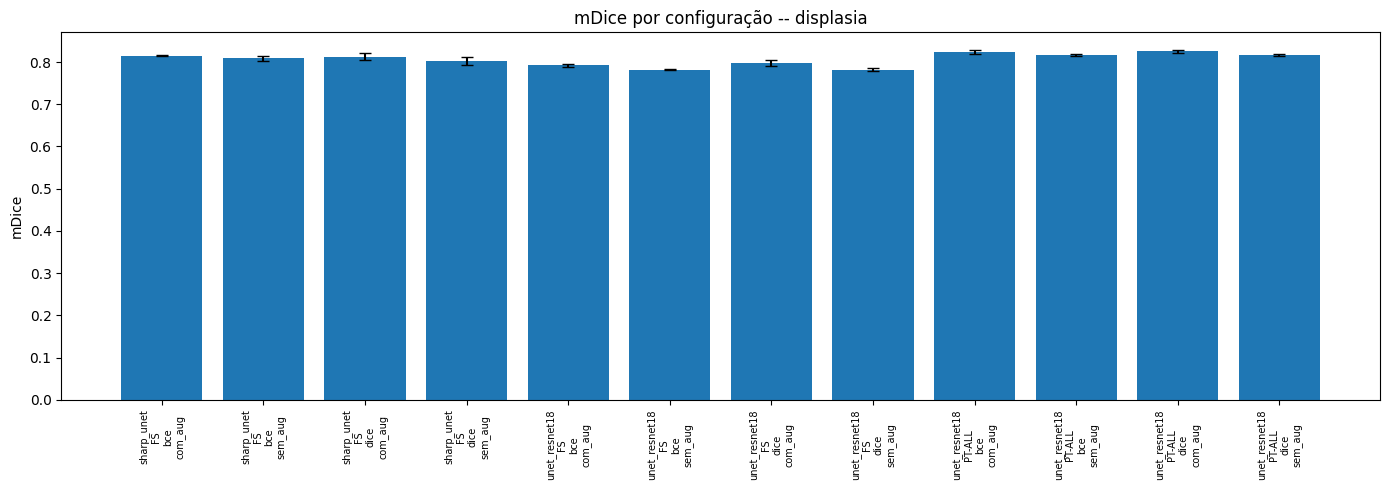

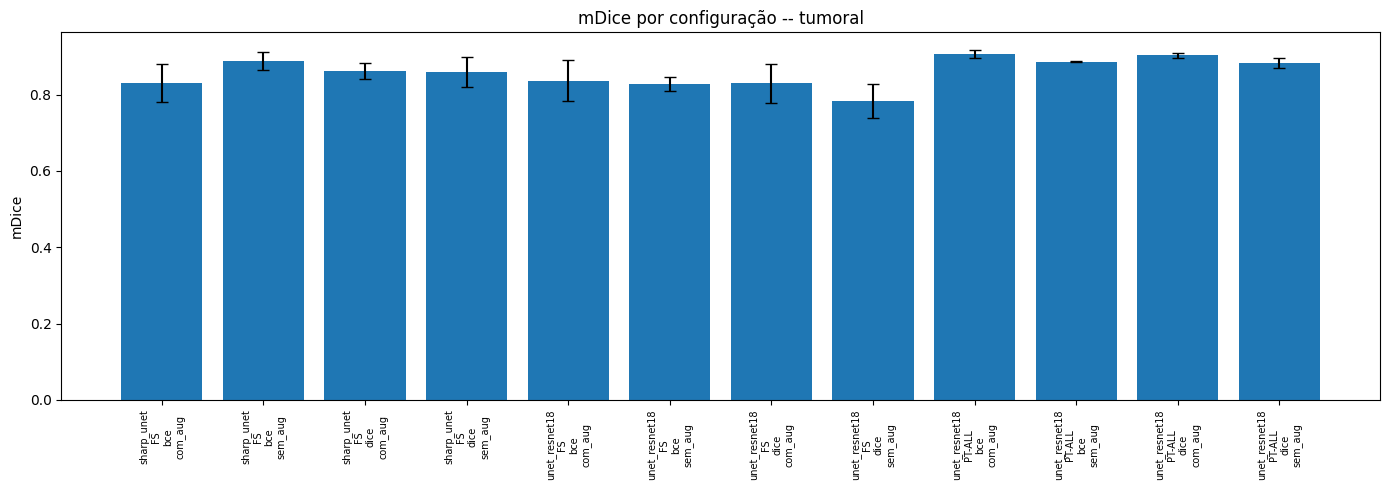

In [63]:
def plot_metric_bars(df, dataset_name, metric_mean_col, metric_std_col, ylabel, save_name):
    df_ds = df[df['dataset'] == dataset_name].copy()
    df_ds['config'] = df_ds['model'] + '\n' + df_ds['training_mode'] + '\n' + df_ds['loss'] + '\n' + df_ds['augmentation']
    df_ds = df_ds.sort_values('config')

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(df_ds['config'], df_ds[metric_mean_col], yerr=df_ds[metric_std_col], capsize=4)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} por configuração -- {dataset_name}')
    plt.xticks(rotation=90, fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, save_name))
    plt.show()

if not summary.empty:
    for dataset_name in ['displasia', 'tumoral']:
        plot_metric_bars(summary, dataset_name, 'mDice_mean', 'mDice_std', 'mDice', f'mdice_{dataset_name}.pdf')
else:
    print("Não é possível gerar gráficos de mDice, pois a tabela de resumo ('summary') está vazia.")

#### Gráfico de mIoU por Configuração

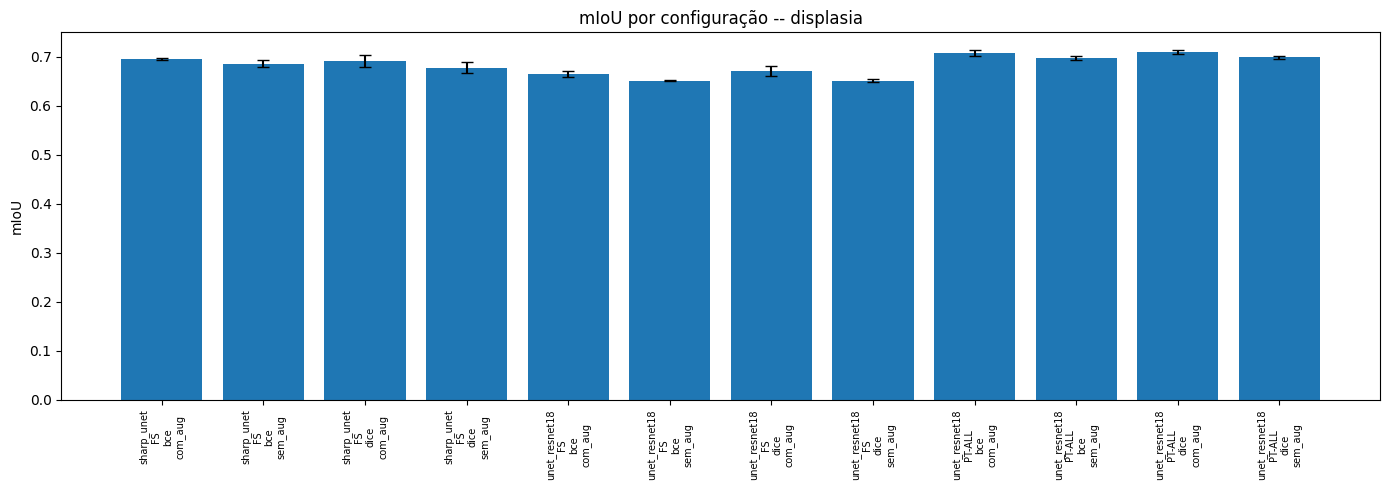

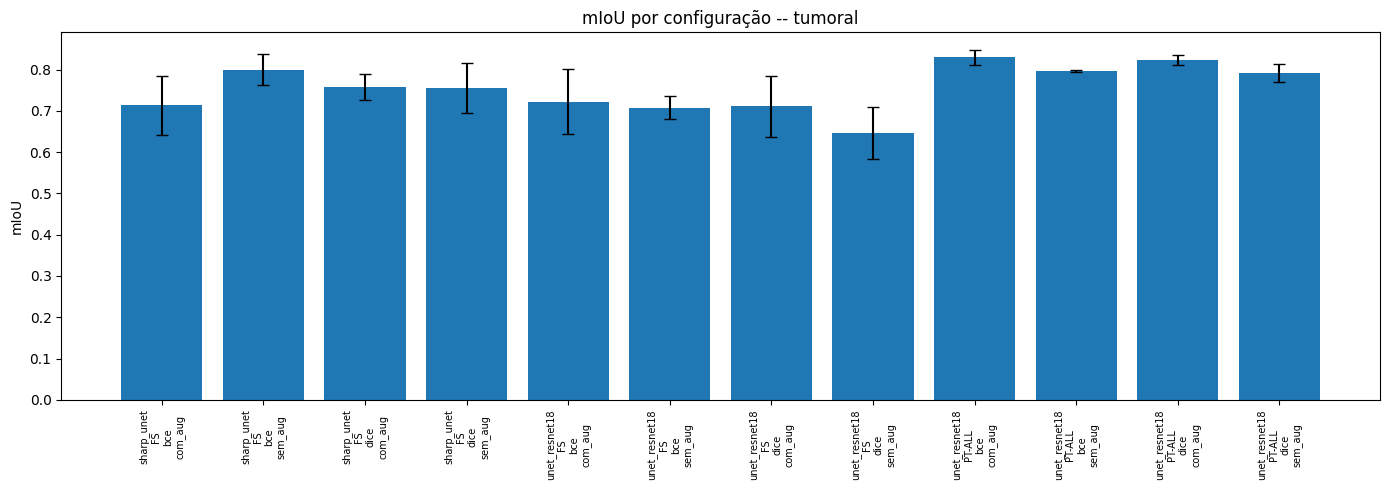

In [64]:
if not summary.empty:
    for dataset_name in ['displasia', 'tumoral']:
        plot_metric_bars(summary, dataset_name, 'mIoU_mean', 'mIoU_std', 'mIoU', f'miou_{dataset_name}.pdf')
else:
    print("Não é possível gerar gráficos de mIoU, pois a tabela de resumo ('summary') está vazia.")

#### Número de Parâmetros por Arquitetura

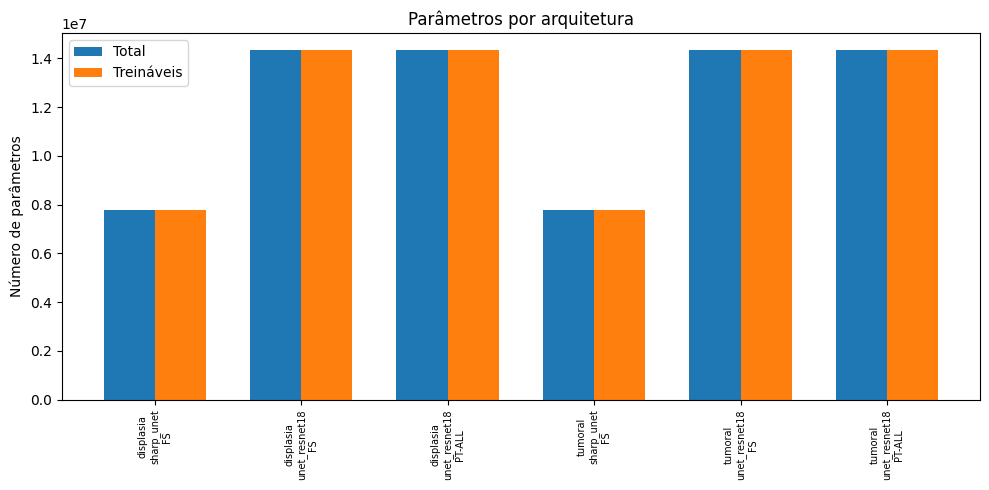

In [65]:
df_arch = df_final.drop_duplicates(subset=['dataset', 'model', 'training_mode'])

if not df_arch.empty:
    df_arch = df_arch.copy()
    df_arch['config'] = df_arch['dataset'] + '\n' + df_arch['model'] + '\n' + df_arch['training_mode']
    df_arch = df_arch.sort_values('config')

    fig, ax = plt.subplots(figsize=(10, 5))
    width = 0.35
    x = np.arange(len(df_arch))
    ax.bar(x - width/2, df_arch['num_params'], width, label='Total')
    ax.bar(x + width/2, df_arch['trainable_params'], width, label='Treináveis')
    ax.set_xticks(x)
    ax.set_xticklabels(df_arch['config'], rotation=90, fontsize=7)
    ax.set_ylabel('Número de parâmetros')
    ax.set_title('Parâmetros por arquitetura')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'num_parametros.pdf'))
    plt.show()
else:
    print("Não é possível gerar o gráfico de parâmetros, pois 'df_final' está vazio ou contém apenas dados duplicados de preenchimento.")

#### Complexidade Computacional (GFLOPs)

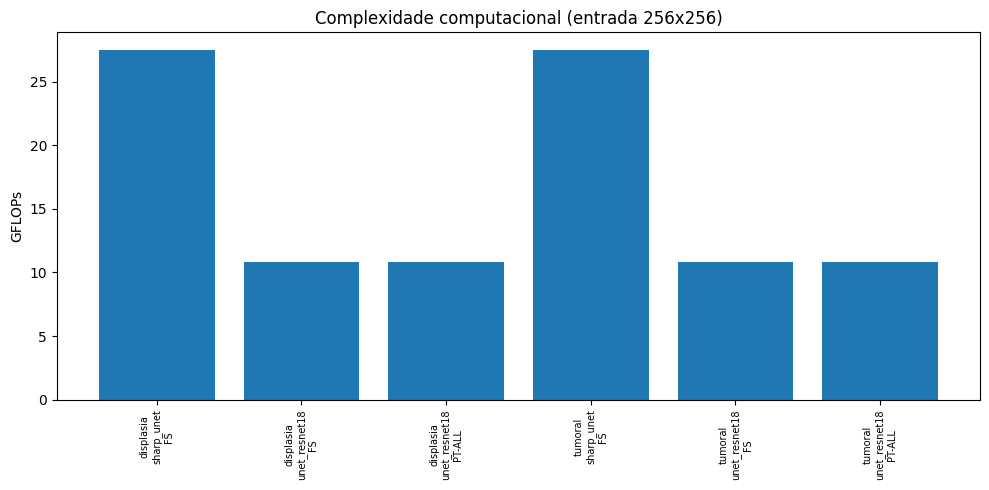

In [66]:
# df_arch é definido na célula anterior.
# Se a célula anterior foi executada e df_arch está vazio, não é possível gerar este gráfico.
if 'df_arch' in locals() and not df_arch.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(df_arch['config'], df_arch['gflops'])
    ax.set_ylabel('GFLOPs')
    ax.set_title(f'Complexidade computacional (entrada {INPUT_SIZE}x{INPUT_SIZE})')
    plt.xticks(rotation=90, fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'gflops.pdf'))
    plt.show()
else:
    print("Não é possível gerar o gráfico de GFLOPs, pois 'df_arch' está vazio ou não foi definido corretamente.")

#### Curvas de Aprendizado

In [67]:
curve_files = [f for f in os.listdir(CURVES_DIR) if f.endswith('.json')]
print(f'{len(curve_files)} curvas encontradas em {CURVES_DIR}')

for fname in curve_files:
    run_id = fname.replace('.json', '')
    with open(os.path.join(CURVES_DIR, fname)) as f:
        history = json.load(f)

    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history['train_loss'], label='Treino')
    axes[0].plot(epochs, history['val_loss'], label='Validação')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss por época')
    axes[0].legend()

    axes[1].plot(epochs, history['val_mDice'])
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('mDice (validação)')
    axes[1].set_title('mDice de validação por época')

    fig.suptitle(run_id, fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(CURVES_PLOTS_DIR, f'{run_id}.pdf'))
    plt.close(fig)

print('Curvas salvas em', CURVES_PLOTS_DIR)

72 curvas encontradas em /content/drive/MyDrive/Central/Estudo/LIPAI - Lab de Pesquisa em Imagens/Onboarding/projeto 3/Repositorio/results/curves_json
Curvas salvas em /content/drive/MyDrive/projeto 3/Repositorio/results/plots_pdf/curvas_aprendizado


#### Arquiteturas e Dataset Classes Pra Inferência

In [68]:
class SharpBlock(nn.Module):
    """
    Bloco de sharpening do Sharp U-Net (Zunair & Ben Hamza, 2021).
    """
    def __init__(self, in_channels):
        super(SharpBlock, self).__init__()
        # Eq. 1: kernel Laplaciano de 8 vizinhos
        kernel = torch.tensor([[-1., -1., -1.],
                                [-1.,  8., -1.],
                                [-1., -1., -1.]], dtype=torch.float32)
        kernel = kernel.repeat(in_channels, 1, 1, 1)
        # kernel fixo: nao eh atualizado durante o treinamento
        self.weight = nn.Parameter(kernel, requires_grad=False)
        self.in_channels = in_channels

    def forward(self, x):
        # Eq. 2: S = I + K * I (convolucao seguida de soma explicita)
        conv_out = F.conv2d(x, self.weight, padding=1, groups=self.in_channels)
        return x + conv_out


class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)


class SharpUNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=1, features=[32, 64, 128, 256]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.sharp_blocks = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        curr_in = in_channels
        for feat in features:
            self.downs.append(ConvBlock(curr_in, feat))
            self.sharp_blocks.append(SharpBlock(feat))
            curr_in = feat

        self.bottleneck = ConvBlock(features[-1], features[-1] * 2)

        for feat in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feat * 2, feat, kernel_size=2, stride=2))
            self.ups.append(ConvBlock(feat * 2, feat))

        self.final_conv = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for i, down in enumerate(self.downs):
            x = down(x)
            sharp_skip = self.sharp_blocks[i](x)
            skip_connections.append(sharp_skip)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skip_connections[idx // 2]
            if x.shape != skip.shape:
                x = TF.resize(x, size=skip.shape[2:])
            concat_x = torch.cat((skip, x), dim=1)
            x = self.ups[idx + 1](concat_x)

        return self.final_conv(x)


def build_model(model_name, training_mode, in_channels=3, num_classes=1):
    if model_name == 'sharp_unet':
        return SharpUNet(in_channels=in_channels, num_classes=num_classes)
    elif model_name == 'unet_resnet18':
        weights = 'imagenet' if training_mode == 'PT-ALL' else None
        return smp.Unet(
            encoder_name='resnet18',
            encoder_weights=weights,
            in_channels=in_channels,
            classes=num_classes
        )
    else:
        raise ValueError(f'Modelo desconhecido: {model_name}')


def get_eval_transform(img_size=INPUT_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=NORM_MEAN, std=NORM_STD),
        ToTensorV2()
    ])


class DisplasiaEvalDataset(Dataset):
    def __init__(self, df, images_dir, masks_dir, transform):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row['image'])
        mask_path = os.path.join(self.masks_dir, row['mask'])
        image = np.array(Image.open(img_path).convert('RGB'), dtype=np.float32) / 255.0
        mask = (np.array(Image.open(mask_path).convert('L'), dtype=np.float32) > 0).astype(np.float32)
        raw_image = (image * 255).astype(np.uint8)
        augmented = self.transform(image=image, mask=mask)
        return augmented['image'], augmented['mask'].unsqueeze(0), raw_image


class TumoralEvalDataset(Dataset):
    def __init__(self, df, dataset_dir, transform):
        self.df = df.reset_index(drop=True)
        self.dataset_dir = dataset_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.dataset_dir, row['image'])
        mask_path = os.path.join(self.dataset_dir, row['mask'])
        image = np.array(Image.open(img_path).convert('RGB'), dtype=np.float32) / 255.0
        mask = (np.array(Image.open(mask_path).convert('L'), dtype=np.float32) >= 128).astype(np.float32)
        raw_image = (image * 255).astype(np.uint8)
        augmented = self.transform(image=image, mask=mask)
        return augmented['image'], augmented['mask'].unsqueeze(0), raw_image

#### Mosaicos Qualitativos

Pra cada dataset, pega a configuração com maior mDice de teste, carrega o checkpoint salvo e roda no conjunto de teste inteiro. As `N_QUALITATIVE` amostras do mosaico são escolhidas espalhadas entre o Dice por imagem dos melhores casos aos piores.

In [69]:
@torch.no_grad()
def generate_mosaic(dataset_name, eval_ds, df_final_data, checkpoints_dir, device, n_samples, save_path):
    # Garante que dataset_name exista em df_final_data antes de filtrar
    if dataset_name not in df_final_data['dataset'].unique():
        print(f"Aviso: Dataset '{dataset_name}' não encontrado nos dados de df_final. Não é possível gerar mosaico.")
        return

    df_ds_filtered = df_final_data[df_final_data['dataset'] == dataset_name]
    if df_ds_filtered.empty:
        print(f"Aviso: Nenhum dado encontrado para o dataset '{dataset_name}' em df_final. Não é possível gerar mosaico.")
        return

    best_row = df_ds_filtered.sort_values('mDice_test', ascending=False).iloc[0]
    run_id = best_row['run_id']
    print(f'{dataset_name}: melhor config = {run_id} (mDice teste = {best_row["mDice_test"]:.4f})')

    try:
        model = build_model(best_row['model'], best_row['training_mode']).to(device)
        checkpoint_path = os.path.join(checkpoints_dir, f'best_{run_id}.pth')
        if not os.path.exists(checkpoint_path):
            print(f"Aviso: Checkpoint '{checkpoint_path}' não encontrado. Não é possível gerar mosaico para {dataset_name}.")
            del model # Clean up
            if torch.cuda.is_available(): torch.cuda.empty_cache()
            return
        state_dict = torch.load(checkpoint_path)
        # remove chaves 'total_ops'/'total_params' que o thop.profile deixou
        # grudadas em modulos 'container' durante o calculo de GFLOPs no
        # treinamento. Sao buffers de profiling, nao pesos do modelo.
        junk_keys = [k for k in state_dict if k.endswith('total_ops') or k.endswith('total_params')]
        if junk_keys:
            for k in junk_keys:
                state_dict.pop(k)
        model.load_state_dict(state_dict)
        model.eval()
    except ValueError as e:
        print(f"Erro ao construir ou carregar modelo para {dataset_name} (run_id: {run_id}): {e}. Verifique se o nome do modelo/modo de treino é válido ou se o checkpoint está corrompido.")
        return
    except Exception as e:
        print(f"Erro inesperado ao inicializar o modelo para {dataset_name} (run_id: {run_id}): {e}")
        return

    loader = DataLoader(eval_ds, batch_size=8, shuffle=False, num_workers=2)

    dice_scores, all_images, all_masks, all_preds = [], [], [], []
    for images, masks, raw_images in loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs).cpu()
        preds = (probs >= 0.5).float()

        for i in range(images.size(0)):
            p, t = preds[i].view(-1), masks[i].view(-1)
            inter = (2 * (p * t).sum()).item()
            union = (p.sum() + t.sum()).item()
            dice = (inter + 1e-6) / (union + 1e-6) if union > 0 else 0.0 # Handle division by zero
            dice_scores.append(dice)
            all_images.append(raw_images[i].numpy()) # Raw image is uint8
            all_masks.append(masks[i, 0].numpy() * 255) # Scale mask to 0-255 for visualization
            all_preds.append(preds[i, 0].numpy() * 255) # Scale prediction to 0-255 for visualization

    if not dice_scores:
        print(f"Aviso: Nenhuma imagem processada para {dataset_name}. Não é possível gerar mosaico.")
        del model
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        return

    order = np.argsort(dice_scores)
    # Garante que idxs contenha no máximo o número de amostras disponíveis
    n_samples_actual = min(n_samples, len(order))
    idxs = order[np.linspace(0, len(order) - 1, n_samples_actual).astype(int)]

    # Ajusta o tamanho da figura para o número real de amostras
    fig, axes = plt.subplots(n_samples_actual, 4, figsize=(12, 3 * n_samples_actual))
    if n_samples_actual == 1: # Se apenas 1 amostra, axes é 1D
        axes = axes.reshape(1, -1)

    col_titles = ['Imagem', 'Ground Truth', 'Predição', 'Overlay']
    for row_i, idx in enumerate(idxs):
        img, gt, pred = all_images[idx], all_masks[idx], all_preds[idx]

        axes[row_i, 0].imshow(img)
        axes[row_i, 1].imshow(gt, cmap='gray')
        axes[row_i, 2].imshow(pred, cmap='gray')
        axes[row_i, 3].imshow(img)
        # Overlay vermelha para a predição, azul para o ground truth
        mask_overlay = np.zeros((*gt.shape, 4))
        mask_overlay[gt > 0, 2] = 1 # Azul para GT
        mask_overlay[pred > 0, 0] = 1 # Vermelho para Predição
        mask_overlay[gt > 0, 3] = 0.4 # Opacidade para GT
        mask_overlay[pred > 0, 3] = 0.4 # Opacidade para Predição
        axes[row_i, 3].imshow(mask_overlay)

        axes[row_i, 0].set_ylabel(f'Dice {dice_scores[idx]:.2f}', fontsize=8)
        for c in range(4):
            axes[row_i, c].set_xticks([])
            axes[row_i, c].set_yticks([])
            if row_i == 0:
                axes[row_i, c].set_title(col_titles[c], fontsize=10)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


eval_tf = get_eval_transform()

# Verifica se df_final contém dados de execuções reais
has_real_data = False
if not df_final.empty:
    # Considera que há dados reais se pelo menos um 'run_id' não começar com 'dummy_'
    has_real_data = any(not str(run_id).startswith('dummy_') for run_id in df_final['run_id'])

if not has_real_data:
    print("Não é possível gerar mosaicos qualitativos, pois 'df_final' não contém dados de execuções reais. Por favor, verifique se 'resultados_displasia.csv' e 'resultados_tumoral.csv' foram carregados corretamente.")
else:
    # Lógica para displasia
    try:
        df_splits_displasia = pd.read_csv(DISPLASIA_SPLITS_CSV)
        test_displasia = df_splits_displasia[df_splits_displasia['split'] == 'test']
        ds_displasia = DisplasiaEvalDataset(test_displasia, DISPLASIA_IMAGES_DIR, DISPLASIA_MASKS_DIR, eval_tf)
        generate_mosaic('displasia', ds_displasia, df_final, CHECKPOINTS_DIR, device, N_QUALITATIVE,
                         os.path.join(QUALITATIVE_DIR, 'mosaico_displasia.png'))
    except FileNotFoundError as e:
        print(f"Aviso: Não foi possível carregar o arquivo de splits para displasia ('{DISPLASIA_SPLITS_CSV}'). {e}")
    except Exception as e:
        print(f"Erro ao gerar mosaico para displasia: {e}")

    # Lógica para tumoral
    try:
        df_splits_tumoral = pd.read_csv(TUMORAL_SPLITS_CSV)
        test_tumoral = df_splits_tumoral[df_splits_tumoral['split'] == 'test']
        ds_tumoral = TumoralEvalDataset(test_tumoral, TUMORAL_DIR, eval_tf)
        generate_mosaic('tumoral', ds_tumoral, df_final, CHECKPOINTS_DIR, device, N_QUALITATIVE,
                         os.path.join(QUALITATIVE_DIR, 'mosaico_tumoral.png'))
    except FileNotFoundError as e:
        print(f"Aviso: Não foi possível carregar o arquivo de splits para tumoral ('{TUMORAL_SPLITS_CSV}'). {e}")
    except Exception as e:
        print(f"Erro ao gerar mosaico para tumoral: {e}")

Output hidden; open in https://colab.research.google.com to view.

#  Analises
1. Validação do desenho experimental


In [70]:

# ============================================================
# 1. VALIDAÇÃO DO DESENHO EXPERIMENTAL
# ============================================================

print("=" * 70)
print("VALIDAÇÃO DO DESENHO EXPERIMENTAL")
print("=" * 70)

print(f"\nTotal de execuções: {len(df_final)}")

print("\nExecuções por dataset:")
display(
    df_final.groupby('dataset')
    .size()
    .rename('n_execucoes')
    .reset_index()
)

# Seeds esperadas
SEEDS_ESPERADAS = {42, 123, 2025}

print("\nSeeds encontradas:")
print(sorted(df_final['seed'].unique()))

# ------------------------------------------------------------
# Duplicatas
# ------------------------------------------------------------

chaves = [
    'dataset',
    'model',
    'training_mode',
    'loss',
    'augmentation',
    'seed'
]

duplicadas = df_final[
    df_final.duplicated(
        subset=chaves,
        keep=False
    )
]

if duplicadas.empty:
    print("\n✓ Nenhuma execução duplicada.")
else:
    print("\n✗ Foram encontradas execuções duplicadas:")
    display(duplicadas[chaves + ['run_id']])


# ------------------------------------------------------------
# Número de seeds por configuração
# ------------------------------------------------------------

config_cols = [
    'dataset',
    'model',
    'training_mode',
    'loss',
    'augmentation'
]

validacao_seeds = (
    df_final
    .groupby(config_cols)
    .agg(
        n_seeds=('seed', 'nunique'),
        seeds=('seed', lambda x: sorted(x.unique())),
        n_execucoes=('run_id', 'count')
    )
    .reset_index()
)

problemas = validacao_seeds[
    (validacao_seeds['n_seeds'] != 3) |
    (validacao_seeds['n_execucoes'] != 3)
]

display(validacao_seeds)

if problemas.empty:
    print("\n✓ Todas as configurações possuem exatamente 3 seeds.")
else:
    print("\n✗ Existem configurações incompletas:")
    display(problemas)


# ------------------------------------------------------------
# Resultado final
# ------------------------------------------------------------

if len(df_final) == 72 and problemas.empty and duplicadas.empty:
    print("\n✅ DESENHO EXPERIMENTAL COMPLETO: 72/72 EXECUÇÕES")
else:
    print("\n⚠️ VERIFICAR DESENHO EXPERIMENTAL")

VALIDAÇÃO DO DESENHO EXPERIMENTAL

Total de execuções: 72

Execuções por dataset:


,dataset,n_execucoes
0,displasia,36
1,tumoral,36



Seeds encontradas:
[np.int64(42), np.int64(123), np.int64(2025)]

✓ Nenhuma execução duplicada.


,dataset,model,training_mode,loss,augmentation,n_seeds,seeds,n_execucoes
0,displasia,sharp_unet,FS,bce,com_aug,3,"[42, 123, 2025]",3
1,displasia,sharp_unet,FS,bce,sem_aug,3,"[42, 123, 2025]",3
2,displasia,sharp_unet,FS,dice,com_aug,3,"[42, 123, 2025]",3
3,displasia,sharp_unet,FS,dice,sem_aug,3,"[42, 123, 2025]",3
4,displasia,unet_resnet18,FS,bce,com_aug,3,"[42, 123, 2025]",3
5,displasia,unet_resnet18,FS,bce,sem_aug,3,"[42, 123, 2025]",3
6,displasia,unet_resnet18,FS,dice,com_aug,3,"[42, 123, 2025]",3
7,displasia,unet_resnet18,FS,dice,sem_aug,3,"[42, 123, 2025]",3
8,displasia,unet_resnet18,PT-ALL,bce,com_aug,3,"[42, 123, 2025]",3
9,displasia,unet_resnet18,PT-ALL,bce,sem_aug,3,"[42, 123, 2025]",3



✓ Todas as configurações possuem exatamente 3 seeds.

✅ DESENHO EXPERIMENTAL COMPLETO: 72/72 EXECUÇÕES


2. Tabela-resumo oficial

In [71]:
# ============================================================
# 2. TABELA RESUMO - MÉDIA E DESVIO PADRÃO
# ============================================================

group_cols = [
    'dataset',
    'model',
    'training_mode',
    'loss',
    'augmentation'
]

metricas = [
    'mDice_test',
    'mIoU_test',
    'dice_foreground_test',
    'iou_foreground_test',
    'precision_foreground_test',
    'recall_foreground_test'
]

df_resumo = (
    df_final
    .groupby(group_cols)
    .agg({
        metrica: ['mean', 'std']
        for metrica in metricas
    })
)

# Achata os nomes das colunas
df_resumo.columns = [
    f'{col}_{stat}'
    for col, stat in df_resumo.columns
]

df_resumo = df_resumo.reset_index()

# Número de seeds
n_seeds = (
    df_final
    .groupby(group_cols)
    ['seed']
    .nunique()
    .reset_index(name='n_seeds')
)

df_resumo = df_resumo.merge(
    n_seeds,
    on=group_cols,
    how='left'
)

# Ordenação
df_resumo = df_resumo.sort_values(
    ['dataset', 'mDice_test_mean'],
    ascending=[True, False]
)

display(df_resumo)

df_resumo.to_csv(
    SUMMARY_CSV,
    index=False
)

print(f"\n✓ Tabela resumo salva em:\n{SUMMARY_CSV}")

,dataset,model,training_mode,loss,augmentation,mDice_test_mean,mDice_test_std,mIoU_test_mean,mIoU_test_std,dice_foreground_test_mean,dice_foreground_test_std,iou_foreground_test_mean,iou_foreground_test_std,precision_foreground_test_mean,precision_foreground_test_std,recall_foreground_test_mean,recall_foreground_test_std,n_seeds
10,displasia,unet_resnet18,PT-ALL,dice,com_aug,0.825333,0.003496,0.709533,0.004765,0.750767,0.005845,0.601067,0.007497,0.778067,0.005445,0.725533,0.012800,3
8,displasia,unet_resnet18,PT-ALL,bce,com_aug,0.823400,0.004715,0.707467,0.006401,0.744733,0.007850,0.593333,0.009950,0.800267,0.001343,0.696567,0.014270,3
11,displasia,unet_resnet18,PT-ALL,dice,sem_aug,0.817633,0.002401,0.699300,0.003205,0.737500,0.003601,0.584100,0.004518,0.783100,0.005810,0.696933,0.006700,3
9,displasia,unet_resnet18,PT-ALL,bce,sem_aug,0.816100,0.002464,0.697467,0.003317,0.734367,0.004148,0.580267,0.005229,0.788067,0.010451,0.687767,0.011974,3
0,displasia,sharp_unet,FS,bce,com_aug,0.815300,0.001758,0.695633,0.002060,0.737133,0.007015,0.583700,0.008771,0.761300,0.032619,0.716833,0.043391,3
2,displasia,sharp_unet,FS,dice,com_aug,0.812533,0.008693,0.690733,0.012393,0.739233,0.008919,0.586400,0.011221,0.721733,0.027250,0.758333,0.012616,3
1,displasia,sharp_unet,FS,bce,sem_aug,0.808833,0.005479,0.686267,0.007504,0.730833,0.007300,0.575900,0.009050,0.732467,0.013812,0.729433,0.011900,3
3,displasia,sharp_unet,FS,dice,sem_aug,0.802400,0.008381,0.678133,0.010706,0.719133,0.014636,0.561600,0.017921,0.737400,0.008815,0.702367,0.032005,3
6,displasia,unet_resnet18,FS,dice,com_aug,0.797533,0.007594,0.670800,0.010410,0.716933,0.009506,0.558800,0.011566,0.707233,0.019258,0.727300,0.013896,3
4,displasia,unet_resnet18,FS,bce,com_aug,0.791900,0.004200,0.664733,0.005387,0.702200,0.006324,0.541100,0.007536,0.733833,0.006186,0.673233,0.009288,3



✓ Tabela resumo salva em:
/content/drive/MyDrive/Central/Estudo/LIPAI - Lab de Pesquisa em Imagens/Onboarding/projeto 3/Repositorio/results/tabela_resumo.csv


3. Ranking das melhores configurações

In [72]:
# ============================================================
# 3. RANKING DAS CONFIGURAÇÕES
# ============================================================

ranking_cols = [
    'dataset',
    'model',
    'training_mode',
    'loss',
    'augmentation',
    'mDice_test_mean',
    'mDice_test_std',
    'mIoU_test_mean',
    'mIoU_test_std',
    'dice_foreground_test_mean',
    'precision_foreground_test_mean',
    'recall_foreground_test_mean'
]

for dataset in df_resumo['dataset'].unique():

    print("\n" + "=" * 90)
    print(f"RANKING - {dataset.upper()}")
    print("=" * 90)

    ranking = (
        df_resumo[
            df_resumo['dataset'] == dataset
        ][ranking_cols]
        .sort_values(
            'mDice_test_mean',
            ascending=False
        )
        .reset_index(drop=True)
    )

    ranking.index = ranking.index + 1

    display(
        ranking.style.format({
            'mDice_test_mean': '{:.4f}',
            'mDice_test_std': '{:.4f}',
            'mIoU_test_mean': '{:.4f}',
            'mIoU_test_std': '{:.4f}',
            'dice_foreground_test_mean': '{:.4f}',
            'precision_foreground_test_mean': '{:.4f}',
            'recall_foreground_test_mean': '{:.4f}'
        })
    )


RANKING - DISPLASIA


,dataset,model,training_mode,loss,augmentation,mDice_test_mean,mDice_test_std,mIoU_test_mean,mIoU_test_std,dice_foreground_test_mean,precision_foreground_test_mean,recall_foreground_test_mean
1,displasia,unet_resnet18,PT-ALL,dice,com_aug,0.8253,0.0035,0.7095,0.0048,0.7508,0.7781,0.7255
2,displasia,unet_resnet18,PT-ALL,bce,com_aug,0.8234,0.0047,0.7075,0.0064,0.7447,0.8003,0.6966
3,displasia,unet_resnet18,PT-ALL,dice,sem_aug,0.8176,0.0024,0.6993,0.0032,0.7375,0.7831,0.6969
4,displasia,unet_resnet18,PT-ALL,bce,sem_aug,0.8161,0.0025,0.6975,0.0033,0.7344,0.7881,0.6878
5,displasia,sharp_unet,FS,bce,com_aug,0.8153,0.0018,0.6956,0.0021,0.7371,0.7613,0.7168
6,displasia,sharp_unet,FS,dice,com_aug,0.8125,0.0087,0.6907,0.0124,0.7392,0.7217,0.7583
7,displasia,sharp_unet,FS,bce,sem_aug,0.8088,0.0055,0.6863,0.0075,0.7308,0.7325,0.7294
8,displasia,sharp_unet,FS,dice,sem_aug,0.8024,0.0084,0.6781,0.0107,0.7191,0.7374,0.7024
9,displasia,unet_resnet18,FS,dice,com_aug,0.7975,0.0076,0.6708,0.0104,0.7169,0.7072,0.7273
10,displasia,unet_resnet18,FS,bce,com_aug,0.7919,0.0042,0.6647,0.0054,0.7022,0.7338,0.6732



RANKING - TUMORAL


,dataset,model,training_mode,loss,augmentation,mDice_test_mean,mDice_test_std,mIoU_test_mean,mIoU_test_std,dice_foreground_test_mean,precision_foreground_test_mean,recall_foreground_test_mean
1,tumoral,unet_resnet18,PT-ALL,bce,com_aug,0.9070,0.0107,0.8302,0.0179,0.8947,0.9023,0.8877
2,tumoral,unet_resnet18,PT-ALL,dice,com_aug,0.9030,0.0072,0.8234,0.0120,0.8919,0.8822,0.9025
3,tumoral,sharp_unet,FS,bce,sem_aug,0.8884,0.0233,0.8001,0.0381,0.8726,0.8878,0.8590
4,tumoral,unet_resnet18,PT-ALL,bce,sem_aug,0.8869,0.0019,0.7970,0.0031,0.8740,0.8642,0.8848
5,tumoral,unet_resnet18,PT-ALL,dice,sem_aug,0.8833,0.0136,0.7913,0.0218,0.8704,0.8585,0.8833
6,tumoral,sharp_unet,FS,dice,com_aug,0.8621,0.0200,0.7581,0.0312,0.8541,0.8027,0.9153
7,tumoral,sharp_unet,FS,dice,sem_aug,0.8601,0.0388,0.7560,0.0606,0.8532,0.8046,0.9139
8,tumoral,unet_resnet18,FS,bce,com_aug,0.8372,0.0533,0.7224,0.0787,0.8298,0.7733,0.8967
9,tumoral,sharp_unet,FS,bce,com_aug,0.8313,0.0496,0.7136,0.0723,0.8220,0.7836,0.8719
10,tumoral,unet_resnet18,FS,dice,com_aug,0.8299,0.0513,0.7116,0.0737,0.8238,0.7664,0.8946


4. **Comparações dos fatores**
4.1 Arquitetura

In [73]:
# ============================================================
# 4.1 EFEITO DA ARQUITETURA
# ============================================================

comparacao_modelo = (
    df_final
    .groupby(['dataset', 'model'])
    ['mDice_test']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .sort_values(
        ['dataset', 'mean'],
        ascending=[True, False]
    )
)

display(comparacao_modelo)

,dataset,model,mean,std,count
0,displasia,sharp_unet,0.809767,0.007616,12
1,displasia,unet_resnet18,0.804438,0.017777,24
2,tumoral,sharp_unet,0.860483,0.036576,12
3,tumoral,unet_resnet18,0.857500,0.049649,24


4.2 BCE × Dice

In [74]:
# ============================================================
# 4.2 EFEITO DA FUNÇÃO DE PERDA
# ============================================================

comparacao_loss = (
    df_final
    .groupby(['dataset', 'loss'])
    ['mDice_test']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

display(comparacao_loss)

,dataset,loss,mean,std,count
0,displasia,bce,0.806172,0.015443,18
1,displasia,dice,0.806256,0.015491,18
2,tumoral,bce,0.863222,0.042449,18
3,tumoral,dice,0.853767,0.048535,18


4.3 Com × sem augmentation

In [75]:
# ============================================================
# 4.3 EFEITO DO DATA AUGMENTATION
# ============================================================

comparacao_aug = (
    df_final
    .groupby(['dataset', 'augmentation'])
    ['mDice_test']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

display(comparacao_aug)

,dataset,augmentation,mean,std,count
0,displasia,com_aug,0.811000,0.013624,18
1,displasia,sem_aug,0.801428,0.015631,18
2,tumoral,com_aug,0.861761,0.045929,18
3,tumoral,sem_aug,0.855228,0.045528,18


4.4 FS × PT-ALL

Aqui existe uma regra importante: PT-ALL só é aplicável à U-Net com backbone. Portanto não devemos colocar Sharp U-Net nessa comparação. O próprio projeto define PT-ALL somente para a U-Net com encoder pré-treinado.

In [76]:
# ============================================================
# 4.4 EFEITO DO PRÉ-TREINAMENTO
# FS × PT-ALL SOMENTE NA U-NET RESNET18
# ============================================================

df_unet = df_final[
    df_final['model'] == 'unet_resnet18'
].copy()

comparacao_training = (
    df_unet
    .groupby(['dataset', 'training_mode'])
    ['mDice_test']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

display(comparacao_training)

,dataset,training_mode,mean,std,count
0,displasia,FS,0.788258,0.008066,12
1,displasia,PT-ALL,0.820617,0.004959,12
2,tumoral,FS,0.819975,0.043648,12
3,tumoral,PT-ALL,0.895025,0.013294,12


5. Calcular o ganho percentual/diferença

In [77]:
# ============================================================
# 5. DIFERENÇA ENTRE CONDIÇÕES
# ============================================================

def comparar_duas_condicoes(
    dataframe,
    fator,
    condicao_a,
    condicao_b,
    metrica='mDice_test'
):

    resultado = []

    for dataset in dataframe['dataset'].unique():

        df_ds = dataframe[
            dataframe['dataset'] == dataset
        ]

        media_a = df_ds[
            df_ds[fator] == condicao_a
        ][metrica].mean()

        media_b = df_ds[
            df_ds[fator] == condicao_b
        ][metrica].mean()

        diferenca = media_b - media_a

        percentual = (
            diferenca / media_a * 100
            if media_a != 0
            else np.nan
        )

        resultado.append({
            'dataset': dataset,
            'fator': fator,
            'condicao_base': condicao_a,
            'condicao_comparada': condicao_b,
            'media_base': media_a,
            'media_comparada': media_b,
            'diferenca_absoluta': diferenca,
            'variacao_percentual': percentual
        })

    return pd.DataFrame(resultado)

In [78]:
#Augmentation
efeito_aug = comparar_duas_condicoes(
    df_final,
    fator='augmentation',
    condicao_a='sem_aug',
    condicao_b='com_aug'
)

display(efeito_aug)

,dataset,fator,condicao_base,condicao_comparada,media_base,media_comparada,diferenca_absoluta,variacao_percentual
0,displasia,augmentation,sem_aug,com_aug,0.801428,0.811000,0.009572,1.194396
1,tumoral,augmentation,sem_aug,com_aug,0.855228,0.861761,0.006533,0.763929


In [79]:
#Loss
efeito_loss = comparar_duas_condicoes(
    df_final,
    fator='loss',
    condicao_a='bce',
    condicao_b='dice'
)

display(efeito_loss)

,dataset,fator,condicao_base,condicao_comparada,media_base,media_comparada,diferenca_absoluta,variacao_percentual
0,displasia,loss,bce,dice,0.806172,0.806256,0.000083,0.010337
1,tumoral,loss,bce,dice,0.863222,0.853767,-0.009456,-1.095379


In [80]:
#pré-treinamento

# ============================================================
# 4.4 EFEITO DO PRÉ-TREINAMENTO
# FS × PT-ALL SOMENTE NA U-NET RESNET18
# ============================================================

df_unet = df_final[
    df_final['model'] == 'unet_resnet18'
].copy()

comparacao_training = (
    df_unet
    .groupby(['dataset', 'training_mode'])
    ['mDice_test']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

# Display the comparison of training modes (optional, as the original notebook does)
display(comparacao_training)

efeito_pretraining = comparar_duas_condicoes(
    df_unet,
    fator='training_mode',
    condicao_a='FS',
    condicao_b='PT-ALL'
)

display(efeito_pretraining)

,dataset,training_mode,mean,std,count
0,displasia,FS,0.788258,0.008066,12
1,displasia,PT-ALL,0.820617,0.004959,12
2,tumoral,FS,0.819975,0.043648,12
3,tumoral,PT-ALL,0.895025,0.013294,12


,dataset,fator,condicao_base,condicao_comparada,media_base,media_comparada,diferenca_absoluta,variacao_percentual
0,displasia,training_mode,FS,PT-ALL,0.788258,0.820617,0.032358,4.105042
1,tumoral,training_mode,FS,PT-ALL,0.819975,0.895025,0.075050,9.152718


6. Desempenho × custo computacional

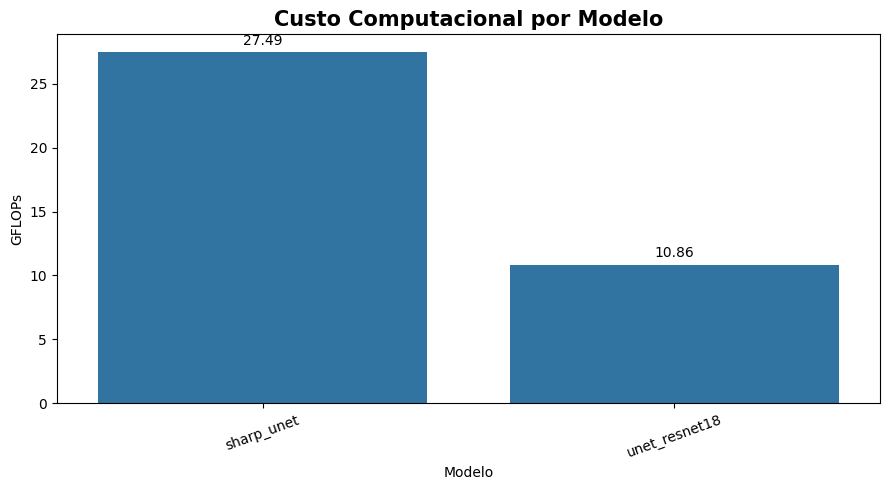

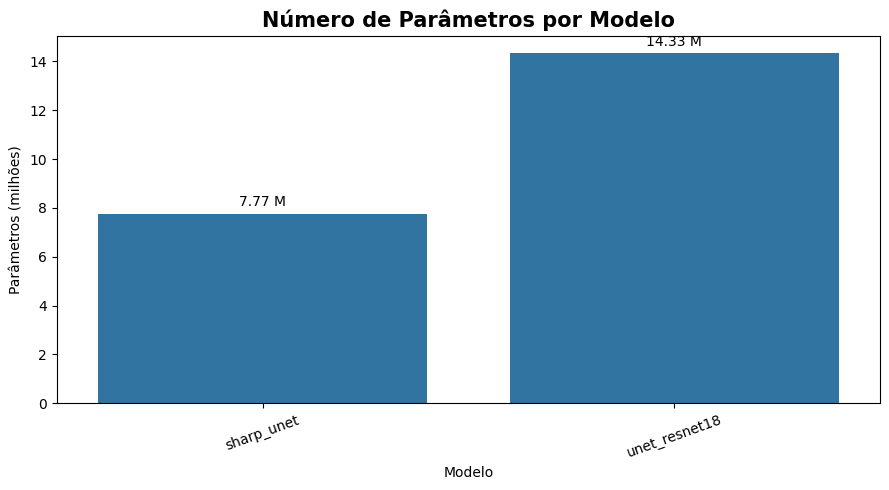

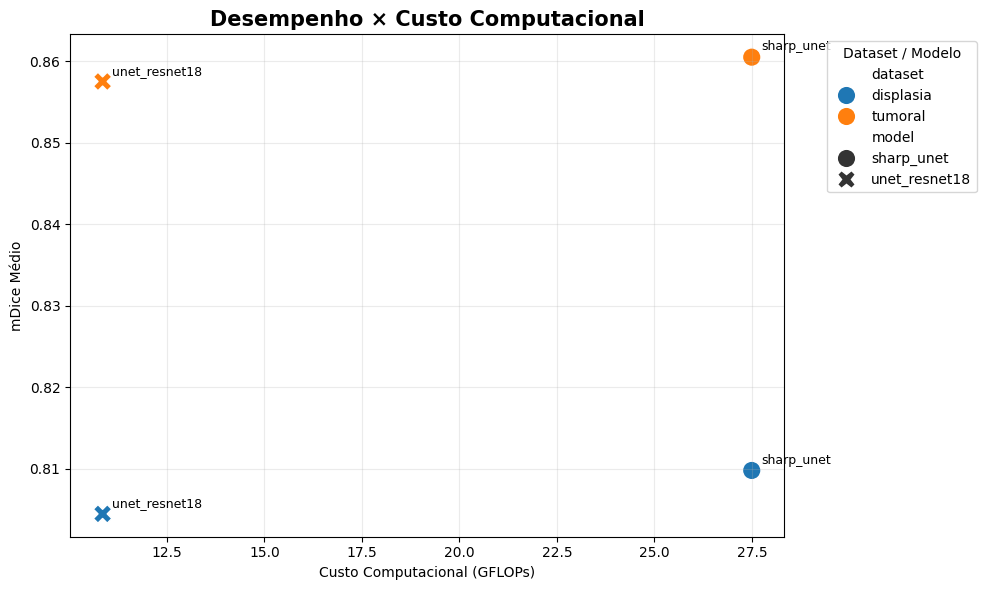

In [81]:
# ============================================================
# 6. CUSTO COMPUTACIONAL
# ============================================================

custo_modelos = (
    df_final
    .groupby('model')
    .agg(
        num_params=('num_params', 'first'),
        trainable_params=('trainable_params', 'first'),
        gflops=('gflops', 'first')
    )
    .reset_index()
)


# ============================================================
# 6.1 GFLOPs POR MODELO
# ============================================================

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=custo_modelos,
    x='model',
    y='gflops'
)

plt.title(
    'Custo Computacional por Modelo',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Modelo')
plt.ylabel('GFLOPs')

plt.xticks(rotation=20)

# Valores sobre as barras
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.tight_layout()
plt.show()


# ============================================================
# 6.2 NÚMERO DE PARÂMETROS
# ============================================================

custo_modelos['num_params_milhoes'] = (
    custo_modelos['num_params'] / 1_000_000
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=custo_modelos,
    x='model',
    y='num_params_milhoes'
)

plt.title(
    'Número de Parâmetros por Modelo',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Modelo')
plt.ylabel('Parâmetros (milhões)')

plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f M',
        padding=3
    )

plt.tight_layout()
plt.show()


# ============================================================
# 6.3 DESEMPENHO × CUSTO COMPUTACIONAL
# ============================================================

desempenho_custo = (
    df_final
    .groupby(['dataset', 'model'])
    .agg(
        mDice_mean=('mDice_test', 'mean'),
        mDice_std=('mDice_test', 'std'),
        gflops=('gflops', 'first'),
        num_params=('num_params', 'first')
    )
    .reset_index()
)


plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=desempenho_custo,
    x='gflops',
    y='mDice_mean',
    hue='dataset',
    style='model',
    s=180
)

plt.title(
    'Desempenho × Custo Computacional',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Custo Computacional (GFLOPs)')
plt.ylabel('mDice Médio')

plt.grid(
    alpha=0.25
)


# Nome do modelo ao lado de cada ponto
for _, row in desempenho_custo.iterrows():

    ax.annotate(
        row['model'],
        (
            row['gflops'],
            row['mDice_mean']
        ),
        xytext=(7, 5),
        textcoords='offset points',
        fontsize=9
    )


plt.legend(
    title='Dataset / Modelo',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

cruzar custo × resultado

In [82]:
desempenho_custo = (
    df_final
    .groupby(['dataset', 'model'])
    .agg(
        mDice_mean=('mDice_test', 'mean'),
        mDice_std=('mDice_test', 'std'),
        gflops=('gflops', 'first'),
        num_params=('num_params', 'first')
    )
    .reset_index()
)

display(desempenho_custo)

,dataset,model,mDice_mean,mDice_std,gflops,num_params
0,displasia,sharp_unet,0.809767,0.007616,27.492,7767361
1,displasia,unet_resnet18,0.804438,0.017777,10.855,14328209
2,tumoral,sharp_unet,0.860483,0.036576,27.492,7767361
3,tumoral,unet_resnet18,0.857500,0.049649,10.855,14328209


# Síntese dos Resultados

In [83]:
# ============================================================
# 7. SÍNTESE AUTOMÁTICA DOS PRINCIPAIS RESULTADOS
# ============================================================

for dataset in df_resumo['dataset'].unique():

    df_ds = df_resumo[
        df_resumo['dataset'] == dataset
    ]

    best = df_ds.loc[
        df_ds['mDice_test_mean'].idxmax()
    ]

    print("\n" + "=" * 80)
    print(f"SÍNTESE - {dataset.upper()}")
    print("=" * 80)

    print(
        "\nMelhor configuração:"
    )

    print(
        f"  Modelo: {best['model']}"
    )

    print(
        f"  Treinamento: {best['training_mode']}"
    )

    print(
        f"  Loss: {best['loss']}"
    )

    print(
        f"  Augmentation: {best['augmentation']}"
    )

    print(
        f"  mDice: "
        f"{best['mDice_test_mean']:.4f} "
        f"± {best['mDice_test_std']:.4f}"
    )

    print(
        f"  mIoU: "
        f"{best['mIoU_test_mean']:.4f} "
        f"± {best['mIoU_test_std']:.4f}"
    )


SÍNTESE - DISPLASIA

Melhor configuração:
  Modelo: unet_resnet18
  Treinamento: PT-ALL
  Loss: dice
  Augmentation: com_aug
  mDice: 0.8253 ± 0.0035
  mIoU: 0.7095 ± 0.0048

SÍNTESE - TUMORAL

Melhor configuração:
  Modelo: unet_resnet18
  Treinamento: PT-ALL
  Loss: bce
  Augmentation: com_aug
  mDice: 0.9070 ± 0.0107
  mIoU: 0.8302 ± 0.0179


8. Validação completa das 72 execuções

In [84]:
# ============================================================
# 8. VALIDAÇÃO COMPLETA DO DESENHO EXPERIMENTAL
# ============================================================

import itertools
import pandas as pd

print("=" * 80)
print("VALIDAÇÃO DO DESENHO EXPERIMENTAL")
print("=" * 80)

# ------------------------------------------------------------
# CONFIGURAÇÕES ESPERADAS
# ------------------------------------------------------------

datasets_esperados = [
    'displasia',
    'tumoral'
]

seeds_esperadas = [
    42,
    123,
    2025
]

losses_esperadas = [
    'bce',
    'dice'
]

augmentations_esperadas = [
    'sem_aug',
    'com_aug'
]

# Sharp U-Net:
# somente FS
sharp_configs = list(
    itertools.product(
        datasets_esperados,
        ['sharp_unet'],
        ['FS'],
        losses_esperadas,
        augmentations_esperadas,
        seeds_esperadas
    )
)

# U-Net ResNet18:
# FS e PT-ALL
unet_configs = list(
    itertools.product(
        datasets_esperados,
        ['unet_resnet18'],
        ['FS', 'PT-ALL'],
        losses_esperadas,
        augmentations_esperadas,
        seeds_esperadas
    )
)

esperadas = set(
    sharp_configs + unet_configs
)

# ------------------------------------------------------------
# CONFIGURAÇÕES ENCONTRADAS
# ------------------------------------------------------------

cols_config = [
    'dataset',
    'model',
    'training_mode',
    'loss',
    'augmentation',
    'seed'
]

encontradas = set(
    map(
        tuple,
        df_final[cols_config].values
    )
)

faltantes = esperadas - encontradas
extras = encontradas - esperadas

# ------------------------------------------------------------
# DUPLICATAS
# ------------------------------------------------------------

duplicadas = df_final[
    df_final.duplicated(
        subset=cols_config,
        keep=False
    )
]

# ------------------------------------------------------------
# RESULTADOS
# ------------------------------------------------------------

print(f"\nExecuções esperadas : {len(esperadas)}")
print(f"Execuções encontradas: {len(df_final)}")

print("\nPor dataset:")
display(
    df_final
    .groupby('dataset')
    .size()
    .rename('execucoes')
    .reset_index()
)

print("\nPor modelo:")
display(
    df_final
    .groupby(['dataset', 'model', 'training_mode'])
    .size()
    .rename('execucoes')
    .reset_index()
)

if not faltantes:
    print("\n✓ Nenhuma configuração faltante.")
else:
    print(f"\n✗ {len(faltantes)} configurações faltantes:")
    display(
        pd.DataFrame(
            sorted(faltantes),
            columns=cols_config
        )
    )

if not extras:
    print("✓ Nenhuma configuração inesperada.")
else:
    print(f"\n⚠ {len(extras)} configurações inesperadas:")
    display(
        pd.DataFrame(
            sorted(extras),
            columns=cols_config
        )
    )

if duplicadas.empty:
    print("✓ Nenhuma duplicata.")
else:
    print("\n✗ Execuções duplicadas:")
    display(
        duplicadas[
            cols_config + ['run_id']
        ]
    )

if (
    len(df_final) == 72
    and not faltantes
    and not extras
    and duplicadas.empty
):
    print("\n" + "=" * 80)
    print("✅ DESENHO EXPERIMENTAL COMPLETO: 72/72")
    print("=" * 80)
else:
    print("\n⚠️ EXISTEM PROBLEMAS NO DESENHO EXPERIMENTAL")

VALIDAÇÃO DO DESENHO EXPERIMENTAL

Execuções esperadas : 72
Execuções encontradas: 72

Por dataset:


,dataset,execucoes
0,displasia,36
1,tumoral,36



Por modelo:


,dataset,model,training_mode,execucoes
0,displasia,sharp_unet,FS,12
1,displasia,unet_resnet18,FS,12
2,displasia,unet_resnet18,PT-ALL,12
3,tumoral,sharp_unet,FS,12
4,tumoral,unet_resnet18,FS,12
5,tumoral,unet_resnet18,PT-ALL,12



✓ Nenhuma configuração faltante.
✓ Nenhuma configuração inesperada.
✓ Nenhuma duplicata.

✅ DESENHO EXPERIMENTAL COMPLETO: 72/72


9. Tabela estatística final

In [85]:
# ============================================================
# 9. TABELA ESTATÍSTICA FINAL
# ============================================================

group_cols = [
    'dataset',
    'model',
    'training_mode',
    'loss',
    'augmentation'
]

metricas = [
    'mDice_test',
    'mIoU_test',
    'dice_foreground_test',
    'iou_foreground_test',
    'precision_foreground_test',
    'recall_foreground_test'
]

agg_dict = {}

for metrica in metricas:
    agg_dict[metrica] = [
        'mean',
        'std'
    ]

df_analise = (
    df_final
    .groupby(group_cols)
    .agg(agg_dict)
)

df_analise.columns = [
    f'{col}_{stat}'
    for col, stat in df_analise.columns
]

df_analise = df_analise.reset_index()

# Quantidade de seeds
seeds_count = (
    df_final
    .groupby(group_cols)
    ['seed']
    .nunique()
    .reset_index(
        name='n_seeds'
    )
)

df_analise = df_analise.merge(
    seeds_count,
    on=group_cols,
    how='left'
)

df_analise = df_analise.sort_values(
    [
        'dataset',
        'mDice_test_mean'
    ],
    ascending=[
        True,
        False
    ]
)

display(df_analise)

print(
    f"\nTotal de configurações consolidadas: "
    f"{len(df_analise)}"
)

,dataset,model,training_mode,loss,augmentation,mDice_test_mean,mDice_test_std,mIoU_test_mean,mIoU_test_std,dice_foreground_test_mean,dice_foreground_test_std,iou_foreground_test_mean,iou_foreground_test_std,precision_foreground_test_mean,precision_foreground_test_std,recall_foreground_test_mean,recall_foreground_test_std,n_seeds
10,displasia,unet_resnet18,PT-ALL,dice,com_aug,0.825333,0.003496,0.709533,0.004765,0.750767,0.005845,0.601067,0.007497,0.778067,0.005445,0.725533,0.012800,3
8,displasia,unet_resnet18,PT-ALL,bce,com_aug,0.823400,0.004715,0.707467,0.006401,0.744733,0.007850,0.593333,0.009950,0.800267,0.001343,0.696567,0.014270,3
11,displasia,unet_resnet18,PT-ALL,dice,sem_aug,0.817633,0.002401,0.699300,0.003205,0.737500,0.003601,0.584100,0.004518,0.783100,0.005810,0.696933,0.006700,3
9,displasia,unet_resnet18,PT-ALL,bce,sem_aug,0.816100,0.002464,0.697467,0.003317,0.734367,0.004148,0.580267,0.005229,0.788067,0.010451,0.687767,0.011974,3
0,displasia,sharp_unet,FS,bce,com_aug,0.815300,0.001758,0.695633,0.002060,0.737133,0.007015,0.583700,0.008771,0.761300,0.032619,0.716833,0.043391,3
2,displasia,sharp_unet,FS,dice,com_aug,0.812533,0.008693,0.690733,0.012393,0.739233,0.008919,0.586400,0.011221,0.721733,0.027250,0.758333,0.012616,3
1,displasia,sharp_unet,FS,bce,sem_aug,0.808833,0.005479,0.686267,0.007504,0.730833,0.007300,0.575900,0.009050,0.732467,0.013812,0.729433,0.011900,3
3,displasia,sharp_unet,FS,dice,sem_aug,0.802400,0.008381,0.678133,0.010706,0.719133,0.014636,0.561600,0.017921,0.737400,0.008815,0.702367,0.032005,3
6,displasia,unet_resnet18,FS,dice,com_aug,0.797533,0.007594,0.670800,0.010410,0.716933,0.009506,0.558800,0.011566,0.707233,0.019258,0.727300,0.013896,3
4,displasia,unet_resnet18,FS,bce,com_aug,0.791900,0.004200,0.664733,0.005387,0.702200,0.006324,0.541100,0.007536,0.733833,0.006186,0.673233,0.009288,3



Total de configurações consolidadas: 24


10. Ranking geral

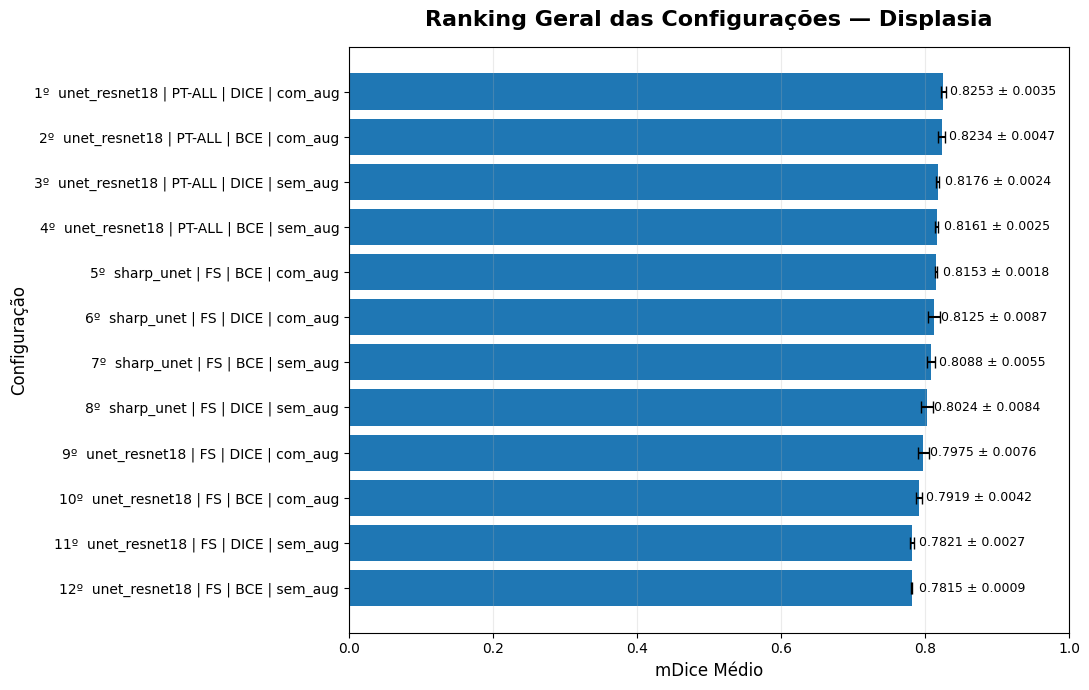

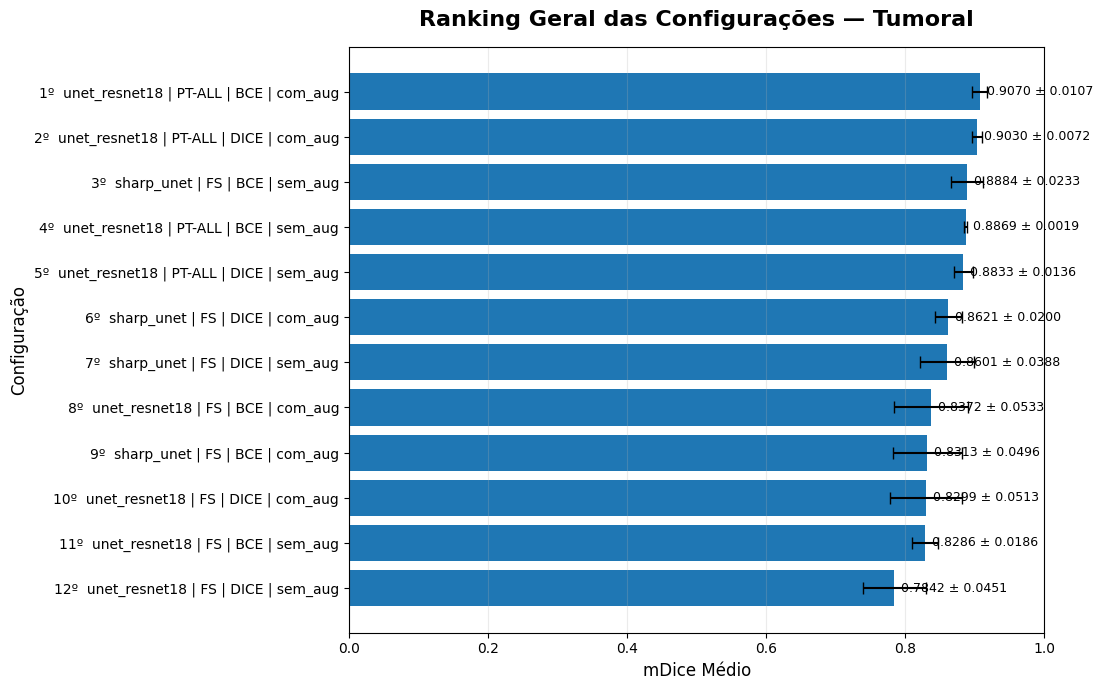

In [86]:
# ============================================================
# 10. RANKING GERAL DAS CONFIGURAÇÕES
# ============================================================

rankings = {}

for dataset in [
    'displasia',
    'tumoral'
]:

    ranking = (
        df_analise[
            df_analise['dataset'] == dataset
        ]
        .sort_values(
            'mDice_test_mean',
            ascending=False
        )
        .reset_index(drop=True)
    )

    ranking.insert(
        0,
        'ranking',
        range(1, len(ranking) + 1)
    )

    rankings[dataset] = ranking

    # ========================================================
    # RÓTULO VISUAL DE CADA CONFIGURAÇÃO
    # ========================================================

    ranking['configuracao'] = (
        ranking['ranking'].astype(str)
        + 'º  '
        + ranking['model'].astype(str)
        + ' | '
        + ranking['training_mode'].astype(str)
        + ' | '
        + ranking['loss'].str.upper()
        + ' | '
        + ranking['augmentation'].astype(str)
    )

    # ========================================================
    # GRÁFICO
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(11, 7)
    )

    # Inverte para o melhor aparecer no topo
    ranking_plot = ranking.iloc[::-1]

    ax.barh(
        ranking_plot['configuracao'],
        ranking_plot['mDice_test_mean'],
        xerr=ranking_plot['mDice_test_std'],
        capsize=4
    )

    ax.set_title(
        f'Ranking Geral das Configurações — {dataset.capitalize()}',
        fontsize=16,
        fontweight='bold',
        pad=15
    )

    ax.set_xlabel(
        'mDice Médio',
        fontsize=12
    )

    ax.set_ylabel(
        'Configuração',
        fontsize=12
    )

    ax.set_xlim(
        0,
        1
    )

    ax.grid(
        axis='x',
        alpha=0.25
    )

    # ========================================================
    # VALORES AO FINAL DAS BARRAS
    # ========================================================

    for i, (_, row) in enumerate(ranking_plot.iterrows()):

        ax.text(
            row['mDice_test_mean'] + 0.01,
            i,
            f"{row['mDice_test_mean']:.4f} ± {row['mDice_test_std']:.4f}",
            va='center',
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

11. Comparação justa das arquiteturas

In [87]:
# ============================================================
# 11. SHARP U-NET × U-NET RESNET18
# COMPARAÇÃO JUSTA: SOMENTE FS
# ============================================================

df_arch = df_final[
    df_final['training_mode'] == 'FS'
].copy()

comparacao_arquitetura = (
    df_arch
    .groupby([
        'dataset',
        'model'
    ])
    .agg(
        mDice_mean=(
            'mDice_test',
            'mean'
        ),
        mDice_std=(
            'mDice_test',
            'std'
        ),
        mIoU_mean=(
            'mIoU_test',
            'mean'
        ),
        precision_mean=(
            'precision_foreground_test',
            'mean'
        ),
        recall_mean=(
            'recall_foreground_test',
            'mean'
        )
    )
    .reset_index()
)

display(
    comparacao_arquitetura
)

,dataset,model,mDice_mean,mDice_std,mIoU_mean,precision_mean,recall_mean
0,displasia,sharp_unet,0.809767,0.007616,0.687692,0.738225,0.726742
1,displasia,unet_resnet18,0.788258,0.008066,0.659483,0.714375,0.686325
2,tumoral,sharp_unet,0.860483,0.036576,0.756925,0.819650,0.890033
3,tumoral,unet_resnet18,0.819975,0.043648,0.697192,0.760225,0.877558


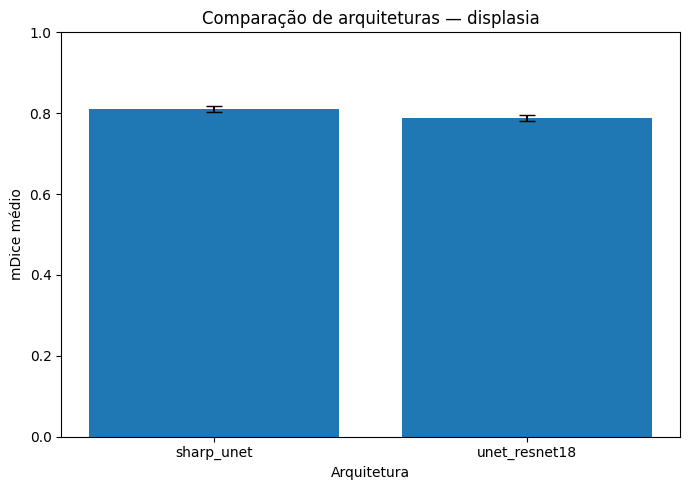

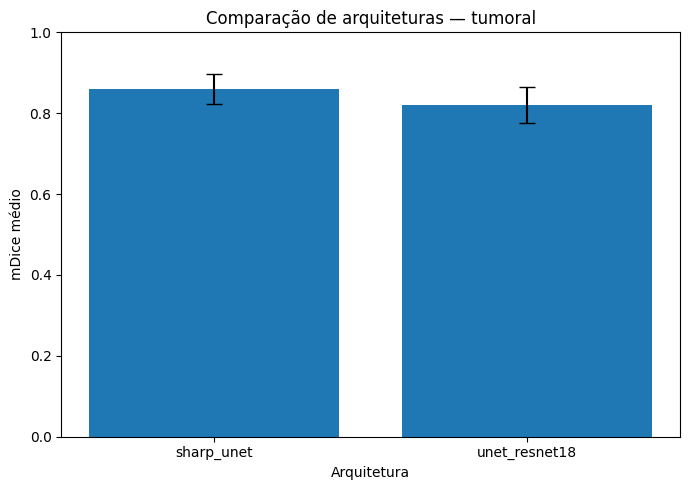

In [88]:
# ============================================================
# GRÁFICO — ARQUITETURAS
# ============================================================

for dataset in [
    'displasia',
    'tumoral'
]:

    temp = comparacao_arquitetura[
        comparacao_arquitetura['dataset']
        == dataset
    ]

    plt.figure(
        figsize=(7, 5)
    )

    plt.bar(
        temp['model'],
        temp['mDice_mean'],
        yerr=temp['mDice_std'],
        capsize=6
    )

    plt.ylabel(
        'mDice médio'
    )

    plt.xlabel(
        'Arquitetura'
    )

    plt.title(
        f'Comparação de arquiteturas — {dataset}'
    )

    plt.ylim(
        0,
        1
    )

    plt.tight_layout()

    plt.show()

12. BCE × Dice Loss

In [89]:
# ============================================================
# 12. BCE × DICE LOSS
# ============================================================

comparacao_loss = (
    df_final
    .groupby([
        'dataset',
        'loss'
    ])
    .agg(
        mDice_mean=(
            'mDice_test',
            'mean'
        ),
        mDice_std=(
            'mDice_test',
            'std'
        ),
        mIoU_mean=(
            'mIoU_test',
            'mean'
        )
    )
    .reset_index()
)

display(
    comparacao_loss
)

,dataset,loss,mDice_mean,mDice_std,mIoU_mean
0,displasia,bce,0.806172,0.015443,0.683739
1,displasia,dice,0.806256,0.015491,0.683339
2,tumoral,bce,0.863222,0.042449,0.761883
3,tumoral,dice,0.853767,0.048535,0.747839


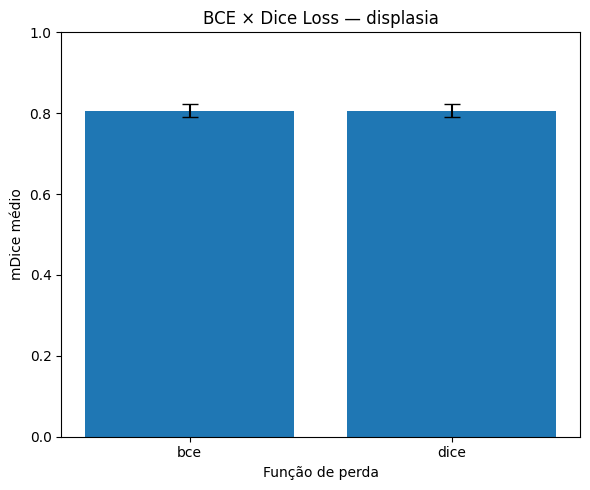

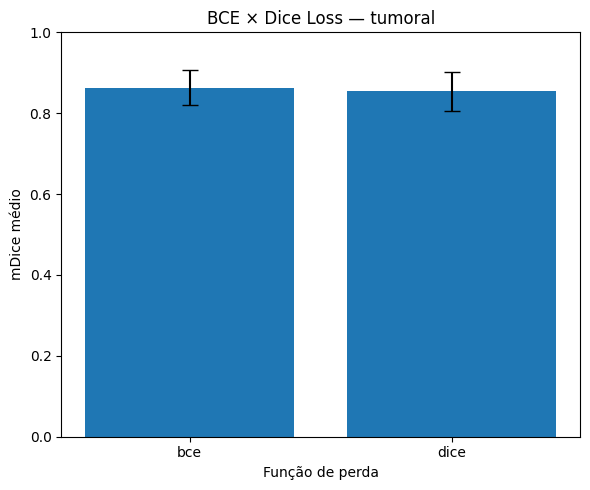

In [90]:
for dataset in [
    'displasia',
    'tumoral'
]:

    temp = comparacao_loss[
        comparacao_loss['dataset']
        == dataset
    ]

    plt.figure(
        figsize=(6, 5)
    )

    plt.bar(
        temp['loss'],
        temp['mDice_mean'],
        yerr=temp['mDice_std'],
        capsize=6
    )

    plt.ylabel(
        'mDice médio'
    )

    plt.xlabel(
        'Função de perda'
    )

    plt.title(
        f'BCE × Dice Loss — {dataset}'
    )

    plt.ylim(
        0,
        1
    )

    plt.tight_layout()

    plt.show()

13. Efeito do Data Augmentation

In [91]:
# ============================================================
# 13. SEM AUGMENTATION × COM AUGMENTATION
# ============================================================

comparacao_aug = (
    df_final
    .groupby([
        'dataset',
        'augmentation'
    ])
    .agg(
        mDice_mean=(
            'mDice_test',
            'mean'
        ),
        mDice_std=(
            'mDice_test',
            'std'
        ),
        mIoU_mean=(
            'mIoU_test',
            'mean'
        )
    )
    .reset_index()
)

display(
    comparacao_aug
)

,dataset,augmentation,mDice_mean,mDice_std,mIoU_mean
0,displasia,com_aug,0.811000,0.013624,0.689817
1,displasia,sem_aug,0.801428,0.015631,0.677261
2,tumoral,com_aug,0.861761,0.045929,0.759872
3,tumoral,sem_aug,0.855228,0.045528,0.749850


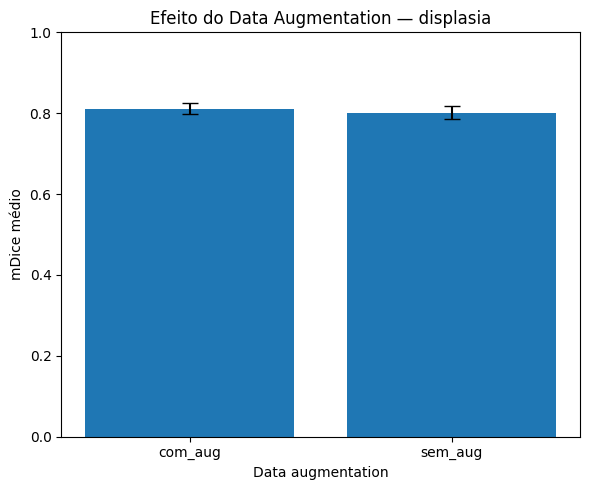

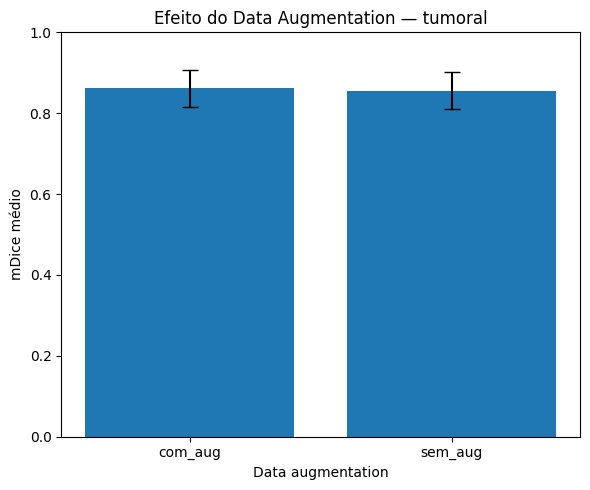

In [92]:
for dataset in [
    'displasia',
    'tumoral'
]:

    temp = comparacao_aug[
        comparacao_aug['dataset']
        == dataset
    ]

    plt.figure(
        figsize=(6, 5)
    )

    plt.bar(
        temp['augmentation'],
        temp['mDice_mean'],
        yerr=temp['mDice_std'],
        capsize=6
    )

    plt.ylabel(
        'mDice médio'
    )

    plt.xlabel(
        'Data augmentation'
    )

    plt.title(
        f'Efeito do Data Augmentation — {dataset}'
    )

    plt.ylim(
        0,
        1
    )

    plt.tight_layout()

    plt.show()

14. FS × PT-ALL

In [93]:
# ============================================================
# 14. FS × PT-ALL
# SOMENTE U-NET RESNET18
# ============================================================

df_pretraining = df_final[
    df_final['model']
    == 'unet_resnet18'
].copy()

comparacao_treinamento = (
    df_pretraining
    .groupby([
        'dataset',
        'training_mode'
    ])
    .agg(
        mDice_mean=(
            'mDice_test',
            'mean'
        ),
        mDice_std=(
            'mDice_test',
            'std'
        ),
        mIoU_mean=(
            'mIoU_test',
            'mean'
        )
    )
    .reset_index()
)

display(
    comparacao_treinamento
)

,dataset,training_mode,mDice_mean,mDice_std,mIoU_mean
0,displasia,FS,0.788258,0.008066,0.659483
1,displasia,PT-ALL,0.820617,0.004959,0.703442
2,tumoral,FS,0.819975,0.043648,0.697192
3,tumoral,PT-ALL,0.895025,0.013294,0.810467


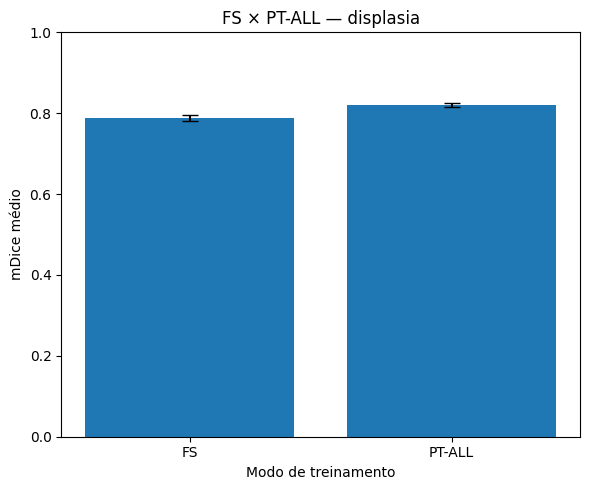

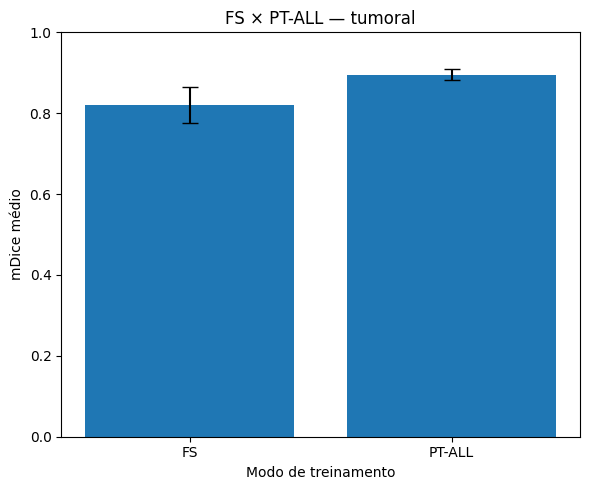

In [94]:
for dataset in [
    'displasia',
    'tumoral'
]:

    temp = comparacao_treinamento[
        comparacao_treinamento['dataset']
        == dataset
    ]

    plt.figure(
        figsize=(6, 5)
    )

    plt.bar(
        temp['training_mode'],
        temp['mDice_mean'],
        yerr=temp['mDice_std'],
        capsize=6
    )

    plt.ylabel(
        'mDice médio'
    )

    plt.xlabel(
        'Modo de treinamento'
    )

    plt.title(
        f'FS × PT-ALL — {dataset}'
    )

    plt.ylim(
        0,
        1
    )

    plt.tight_layout()

    plt.show()

15. Precision × Recall

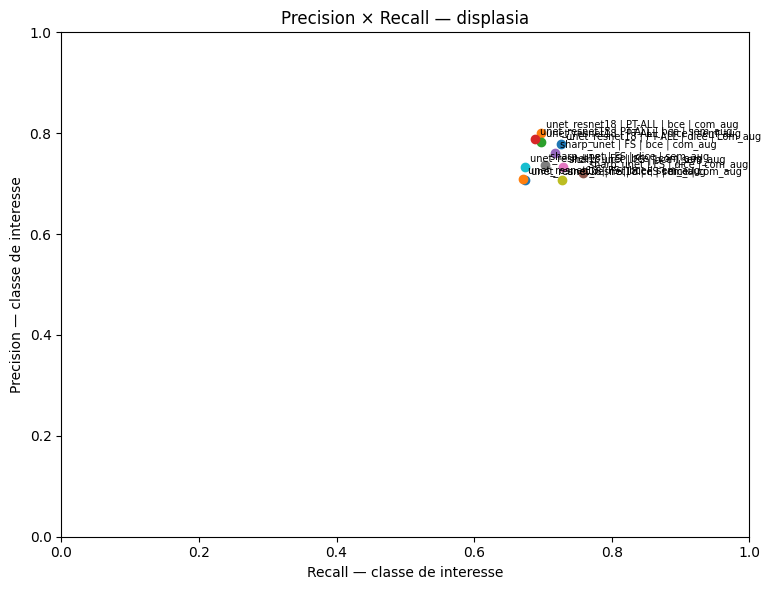

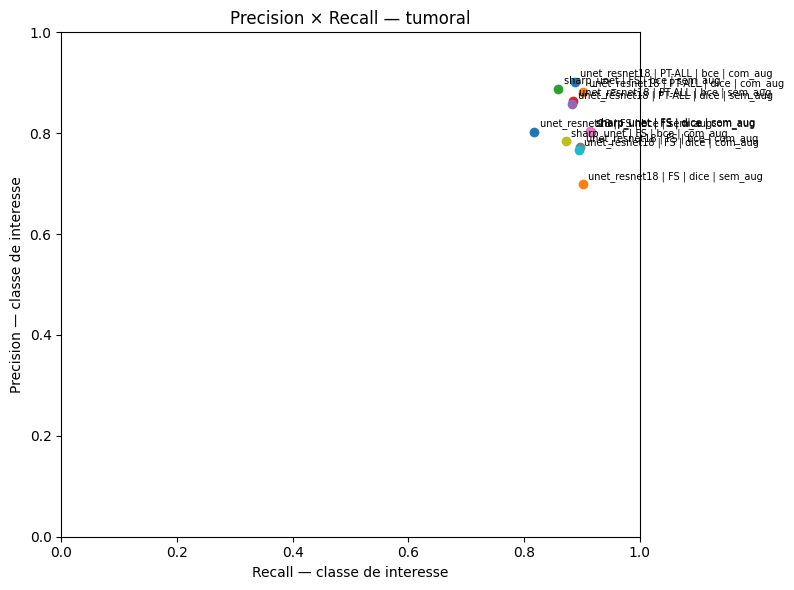

In [95]:
# ============================================================
# 15. PRECISION × RECALL
# ============================================================

precision_recall = (
    df_analise[
        [
            'dataset',
            'model',
            'training_mode',
            'loss',
            'augmentation',
            'precision_foreground_test_mean',
            'recall_foreground_test_mean',
            'mDice_test_mean'
        ]
    ]
    .copy()
)

for dataset in [
    'displasia',
    'tumoral'
]:

    temp = precision_recall[
        precision_recall['dataset']
        == dataset
    ]

    plt.figure(
        figsize=(8, 6)
    )

    for _, row in temp.iterrows():

        plt.scatter(
            row[
                'recall_foreground_test_mean'
            ],
            row[
                'precision_foreground_test_mean'
            ]
        )

        label = (
            f"{row['model']} | "
            f"{row['training_mode']} | "
            f"{row['loss']} | "
            f"{row['augmentation']}"
        )

        plt.annotate(
            label,
            (
                row[
                    'recall_foreground_test_mean'
                ],
                row[
                    'precision_foreground_test_mean'
                ]
            ),
            fontsize=7,
            xytext=(4, 4),
            textcoords='offset points'
        )

    plt.xlabel(
        'Recall — classe de interesse'
    )

    plt.ylabel(
        'Precision — classe de interesse'
    )

    plt.title(
        f'Precision × Recall — {dataset}'
    )

    plt.xlim(
        0,
        1
    )

    plt.ylim(
        0,
        1
    )

    plt.tight_layout()

    plt.show()

16. Custo computacional × desempenho

In [96]:
# ============================================================
# 16. DESEMPENHO × CUSTO COMPUTACIONAL
# ============================================================

df_custo = (
    df_final
    .groupby([
        'dataset',
        'model'
    ])
    .agg(
        mDice_mean=(
            'mDice_test',
            'mean'
        ),
        mDice_std=(
            'mDice_test',
            'std'
        ),
        mIoU_mean=(
            'mIoU_test',
            'mean'
        ),
        num_params=(
            'num_params',
            'first'
        ),
        trainable_params=(
            'trainable_params',
            'first'
        ),
        gflops=(
            'gflops',
            'first'
        )
    )
    .reset_index()
)

df_custo[
    'milhoes_parametros'
] = (
    df_custo[
        'num_params'
    ] / 1_000_000
)

display(
    df_custo
)

,dataset,model,mDice_mean,mDice_std,mIoU_mean,num_params,trainable_params,gflops,milhoes_parametros
0,displasia,sharp_unet,0.809767,0.007616,0.687692,7767361,7763041,27.492,7.767361
1,displasia,unet_resnet18,0.804438,0.017777,0.681462,14328209,14328209,10.855,14.328209
2,tumoral,sharp_unet,0.860483,0.036576,0.756925,7767361,7763041,27.492,7.767361
3,tumoral,unet_resnet18,0.857500,0.049649,0.753829,14328209,14328209,10.855,14.328209


GFLOPs × mDice

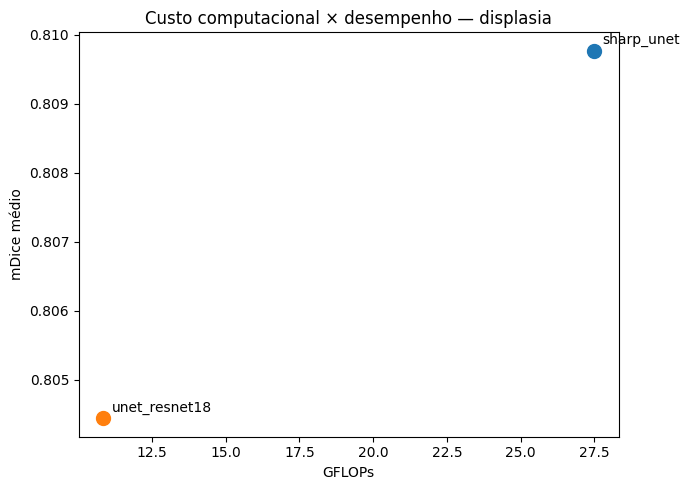

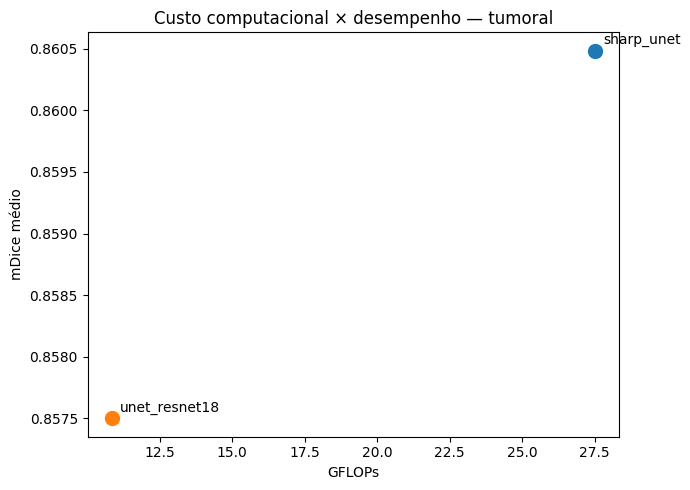

In [97]:
for dataset in [
    'displasia',
    'tumoral'
]:

    temp = df_custo[
        df_custo['dataset']
        == dataset
    ]

    plt.figure(
        figsize=(7, 5)
    )

    for _, row in temp.iterrows():

        plt.scatter(
            row['gflops'],
            row['mDice_mean'],
            s=100
        )

        plt.annotate(
            row['model'],
            (
                row['gflops'],
                row['mDice_mean']
            ),
            xytext=(6, 5),
            textcoords='offset points'
        )

    plt.xlabel(
        'GFLOPs'
    )

    plt.ylabel(
        'mDice médio'
    )

    plt.title(
        f'Custo computacional × desempenho — {dataset}'
    )

    plt.tight_layout()

    plt.show()

Parâmetros × mDice

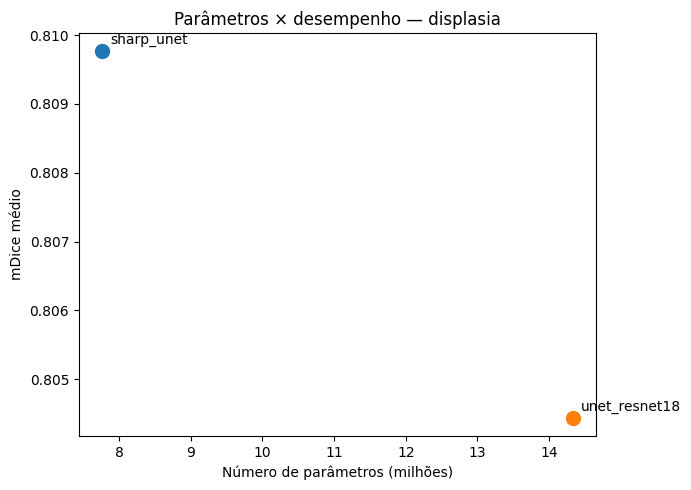

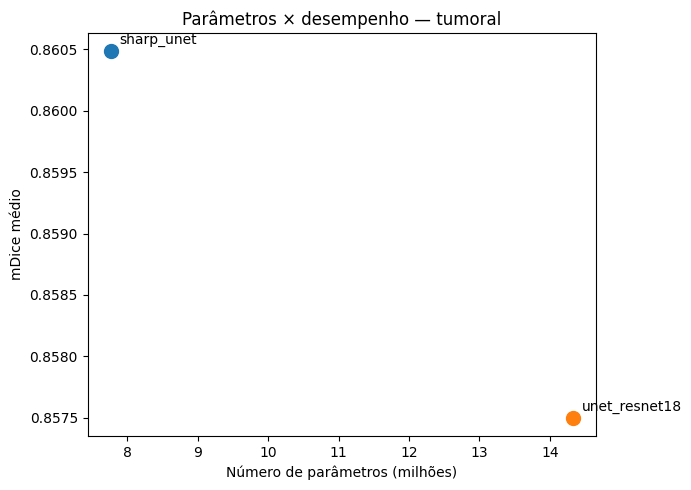

In [98]:
for dataset in [
    'displasia',
    'tumoral'
]:

    temp = df_custo[
        df_custo['dataset']
        == dataset
    ]

    plt.figure(
        figsize=(7, 5)
    )

    for _, row in temp.iterrows():

        plt.scatter(
            row['milhoes_parametros'],
            row['mDice_mean'],
            s=100
        )

        plt.annotate(
            row['model'],
            (
                row['milhoes_parametros'],
                row['mDice_mean']
            ),
            xytext=(6, 5),
            textcoords='offset points'
        )

    plt.xlabel(
        'Número de parâmetros (milhões)'
    )

    plt.ylabel(
        'mDice médio'
    )

    plt.title(
        f'Parâmetros × desempenho — {dataset}'
    )

    plt.tight_layout()

    plt.show()

17. Diagnóstico das curvas de aprendizado

72 curvas encontradas em /content/drive/MyDrive/Central/Estudo/LIPAI - Lab de Pesquisa em Imagens/Onboarding/projeto 3/Repositorio/results/curves_json
✓ 72 curvas analisadas


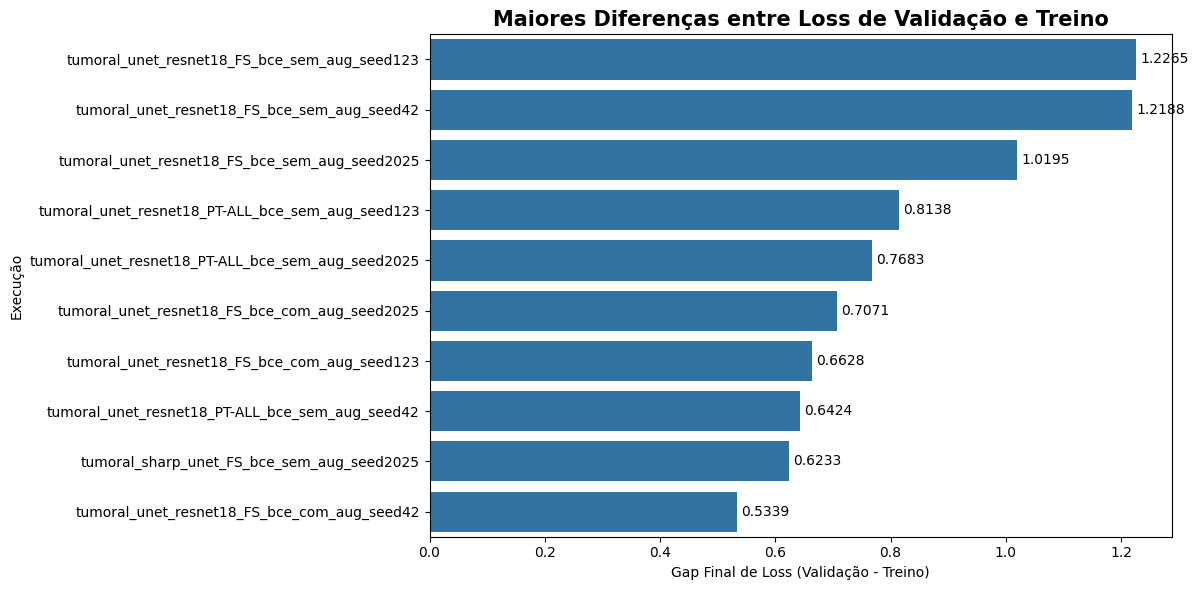

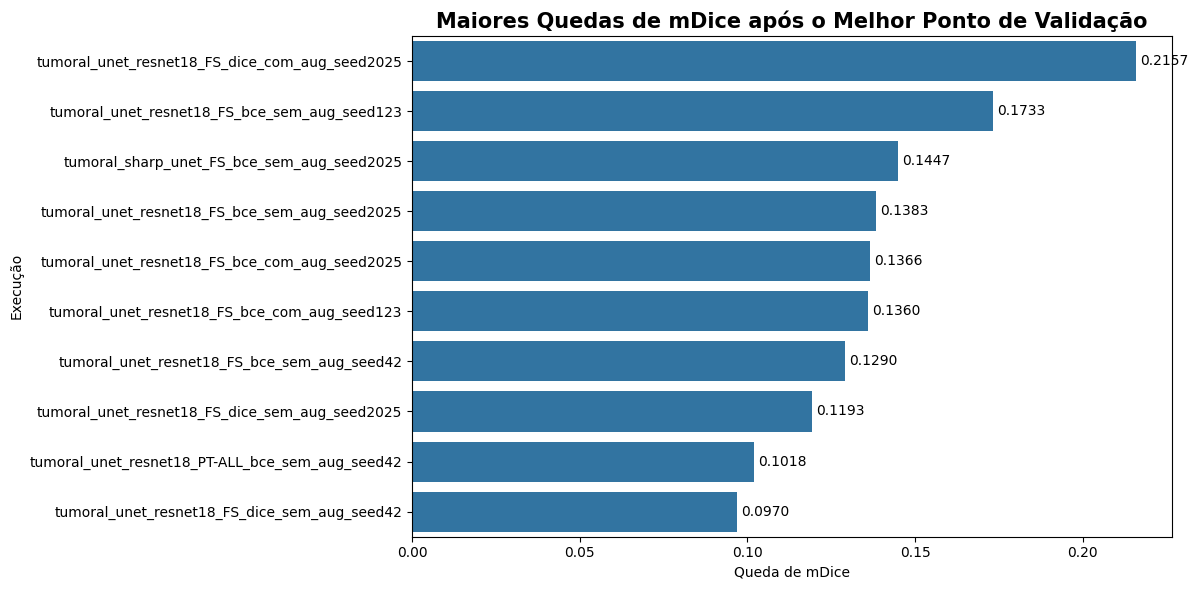

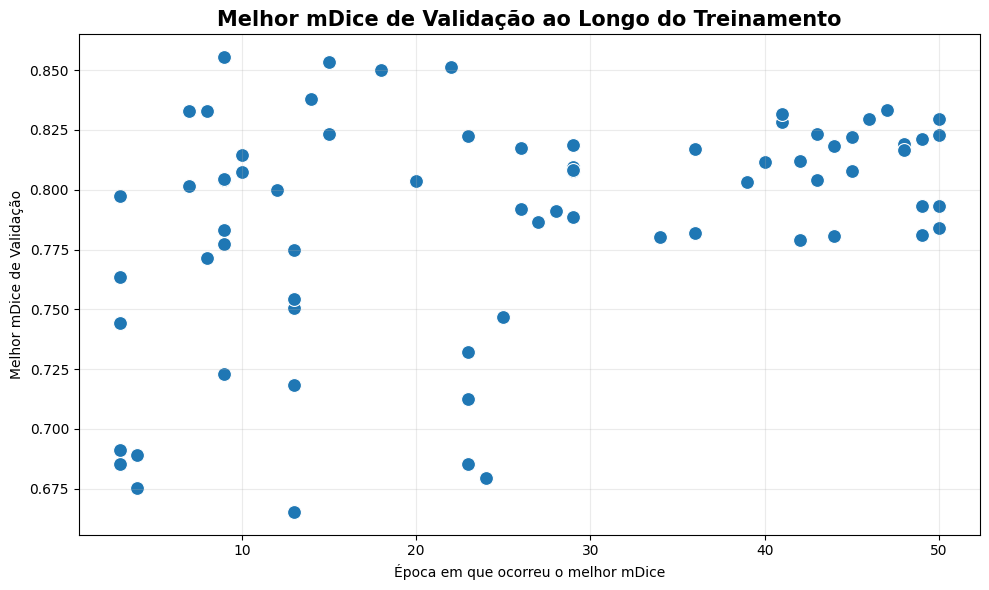

In [99]:
# ============================================================
# 17. DIAGNÓSTICO VISUAL DAS CURVAS DE APRENDIZADO
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


diagnostico_curvas = []

# ------------------------------------------------------------
# 1. LOCALIZA OS ARQUIVOS JSON DAS CURVAS
# ------------------------------------------------------------

curve_files = [
    f
    for f in os.listdir(CURVES_DIR)
    if f.endswith('.json')
]

print(f'{len(curve_files)} curvas encontradas em {CURVES_DIR}')


# ------------------------------------------------------------
# 2. EXTRAI AS INFORMAÇÕES DE CADA EXECUÇÃO
# ------------------------------------------------------------

for fname in curve_files:

    path = os.path.join(
        CURVES_DIR,
        fname
    )

    with open(
        path,
        'r',
        encoding='utf-8'
    ) as f:

        history = json.load(f)

    train_loss = history.get(
        'train_loss',
        []
    )

    val_loss = history.get(
        'val_loss',
        []
    )

    val_mdice = (
        history.get('val_mDice')
        or history.get('val_mdice')
        or history.get('val_dice')
        or []
    )

    # Ignora arquivo inválido
    if not train_loss:
        continue

    run_id = fname.replace(
        '.json',
        ''
    )

    n_epochs = len(
        train_loss
    )

    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    if val_loss:

        min_val_loss = min(
            val_loss
        )

        epoch_min_val_loss = (
            np.argmin(val_loss) + 1
        )

        final_val_loss = val_loss[-1]

    else:

        min_val_loss = np.nan
        epoch_min_val_loss = np.nan
        final_val_loss = np.nan

    # --------------------------------------------------------
    # mDICE
    # --------------------------------------------------------

    if val_mdice:

        best_val_mdice = max(
            val_mdice
        )

        epoch_best_mdice = (
            np.argmax(val_mdice) + 1
        )

        final_val_mdice = val_mdice[-1]

    else:

        best_val_mdice = np.nan
        epoch_best_mdice = np.nan
        final_val_mdice = np.nan

    diagnostico_curvas.append({

        'run_id':
            run_id,

        'epochs':
            n_epochs,

        'initial_train_loss':
            train_loss[0],

        'final_train_loss':
            train_loss[-1],

        'min_val_loss':
            min_val_loss,

        'final_val_loss':
            final_val_loss,

        'epoch_min_val_loss':
            epoch_min_val_loss,

        'best_val_mDice':
            best_val_mdice,

        'final_val_mDice':
            final_val_mdice,

        'epoch_best_mDice':
            epoch_best_mdice
    })


# ------------------------------------------------------------
# 3. DATAFRAME DE DIAGNÓSTICO
# ------------------------------------------------------------

df_curvas = pd.DataFrame(
    diagnostico_curvas
)

if df_curvas.empty:

    raise RuntimeError(
        'Nenhuma curva válida foi encontrada.'
    )


# ------------------------------------------------------------
# 4. INDICADORES DE DIAGNÓSTICO
# ------------------------------------------------------------

df_curvas[
    'loss_gap_final'
] = (
    df_curvas['final_val_loss']
    -
    df_curvas['final_train_loss']
)


df_curvas[
    'queda_mdice_final'
] = (
    df_curvas['best_val_mDice']
    -
    df_curvas['final_val_mDice']
)


df_curvas[
    'epocas_apos_melhor'
] = (
    df_curvas['epochs']
    -
    df_curvas['epoch_best_mDice']
)


print(
    f'✓ {len(df_curvas)} curvas analisadas'
)


# ============================================================
# 17.1 MAIORES GAPS ENTRE LOSS DE VALIDAÇÃO E TREINO
# ============================================================

top_gap = (
    df_curvas
    .dropna(
        subset=['loss_gap_final']
    )
    .sort_values(
        'loss_gap_final',
        ascending=False
    )
    .head(10)
    .copy()
)


plt.figure(
    figsize=(12, 6)
)

ax = sns.barplot(
    data=top_gap,
    x='loss_gap_final',
    y='run_id'
)

plt.title(
    'Maiores Diferenças entre Loss de Validação e Treino',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel(
    'Gap Final de Loss (Validação - Treino)'
)

plt.ylabel(
    'Execução'
)

for container in ax.containers:

    ax.bar_label(
        container,
        fmt='%.4f',
        padding=3
    )

plt.tight_layout()

plt.show()


# ============================================================
# 17.2 MAIORES QUEDAS DE mDICE APÓS O MELHOR PONTO
# ============================================================

top_queda_mdice = (
    df_curvas
    .dropna(
        subset=['queda_mdice_final']
    )
    .sort_values(
        'queda_mdice_final',
        ascending=False
    )
    .head(10)
    .copy()
)


plt.figure(
    figsize=(12, 6)
)

ax = sns.barplot(
    data=top_queda_mdice,
    x='queda_mdice_final',
    y='run_id'
)

plt.title(
    'Maiores Quedas de mDice após o Melhor Ponto de Validação',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel(
    'Queda de mDice'
)

plt.ylabel(
    'Execução'
)

for container in ax.containers:

    ax.bar_label(
        container,
        fmt='%.4f',
        padding=3
    )

plt.tight_layout()

plt.show()


# ============================================================
# 17.3 ÉPOCA DO MELHOR mDICE × MELHOR mDICE
# ============================================================

df_scatter = df_curvas.dropna(
    subset=[
        'epoch_best_mDice',
        'best_val_mDice'
    ]
)


plt.figure(
    figsize=(10, 6)
)

ax = sns.scatterplot(
    data=df_scatter,
    x='epoch_best_mDice',
    y='best_val_mDice',
    s=100
)

plt.title(
    'Melhor mDice de Validação ao Longo do Treinamento',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel(
    'Época em que ocorreu o melhor mDice'
)

plt.ylabel(
    'Melhor mDice de Validação'
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()

In [100]:
df_curvas[
    'loss_gap_final'
] = (
    df_curvas['final_val_loss']
    -
    df_curvas['final_train_loss']
)

df_curvas[
    'queda_mdice_final'
] = (
    df_curvas['best_val_mDice']
    -
    df_curvas['final_val_mDice']
)

df_curvas[
    'epocas_apos_melhor'
] = (
    df_curvas['epochs']
    -
    df_curvas['epoch_best_mDice']
)

Candidatos a possível overfitting

In [101]:
print(
    "Maiores diferenças entre loss de validação e treino:"
)

display(
    df_curvas
    .sort_values(
        'loss_gap_final',
        ascending=False
    )
    .head(10)
)

Maiores diferenças entre loss de validação e treino:


,run_id,epochs,initial_train_loss,final_train_loss,min_val_loss,final_val_loss,epoch_min_val_loss,best_val_mDice,final_val_mDice,epoch_best_mDice,loss_gap_final,queda_mdice_final,epocas_apos_melhor
49,tumoral_unet_resnet18_FS_bce_sem_aug_seed123,15,0.557244,0.161114,0.573154,1.387657,3,0.691100,0.517817,3,1.226543,0.173282,12
48,tumoral_unet_resnet18_FS_bce_sem_aug_seed42,36,0.635285,0.090955,0.630153,1.309720,3,0.679458,0.550464,24,1.218765,0.128994,12
50,tumoral_unet_resnet18_FS_bce_sem_aug_seed2025,15,0.571858,0.168946,0.639538,1.188421,3,0.685447,0.547172,3,1.019475,0.138275,12
61,tumoral_unet_resnet18_PT-ALL_bce_sem_aug_seed123,21,0.589147,0.088859,0.493176,0.902625,9,0.804386,0.718709,9,0.813765,0.085676,12
62,tumoral_unet_resnet18_PT-ALL_bce_sem_aug_seed2025,22,0.581241,0.086563,0.475057,0.854822,10,0.807308,0.712139,10,0.768259,0.095169,12
53,tumoral_unet_resnet18_FS_bce_com_aug_seed2025,15,0.573575,0.287407,0.529176,0.994487,3,0.744319,0.607678,3,0.707080,0.136642,12
52,tumoral_unet_resnet18_FS_bce_com_aug_seed123,25,0.555773,0.250069,0.495690,0.912865,13,0.774696,0.638649,13,0.662796,0.136046,12
60,tumoral_unet_resnet18_PT-ALL_bce_sem_aug_seed42,26,0.659827,0.088711,0.402413,0.731153,14,0.837818,0.735984,14,0.642442,0.101835,12
38,tumoral_sharp_unet_FS_bce_sem_aug_seed2025,50,0.679304,0.126212,0.399911,0.749493,41,0.831861,0.687126,41,0.623281,0.144735,9
51,tumoral_unet_resnet18_FS_bce_com_aug_seed42,41,0.634478,0.195681,0.458594,0.729565,29,0.788733,0.714829,29,0.533884,0.073904,12


In [102]:
print(
    "Maiores diferenças entre loss de validação e treino:"
)

display(
    df_curvas
    .sort_values(
        'loss_gap_final',
        ascending=False
    )
    .head(10)
)

Maiores diferenças entre loss de validação e treino:


,run_id,epochs,initial_train_loss,final_train_loss,min_val_loss,final_val_loss,epoch_min_val_loss,best_val_mDice,final_val_mDice,epoch_best_mDice,loss_gap_final,queda_mdice_final,epocas_apos_melhor
49,tumoral_unet_resnet18_FS_bce_sem_aug_seed123,15,0.557244,0.161114,0.573154,1.387657,3,0.691100,0.517817,3,1.226543,0.173282,12
48,tumoral_unet_resnet18_FS_bce_sem_aug_seed42,36,0.635285,0.090955,0.630153,1.309720,3,0.679458,0.550464,24,1.218765,0.128994,12
50,tumoral_unet_resnet18_FS_bce_sem_aug_seed2025,15,0.571858,0.168946,0.639538,1.188421,3,0.685447,0.547172,3,1.019475,0.138275,12
61,tumoral_unet_resnet18_PT-ALL_bce_sem_aug_seed123,21,0.589147,0.088859,0.493176,0.902625,9,0.804386,0.718709,9,0.813765,0.085676,12
62,tumoral_unet_resnet18_PT-ALL_bce_sem_aug_seed2025,22,0.581241,0.086563,0.475057,0.854822,10,0.807308,0.712139,10,0.768259,0.095169,12
53,tumoral_unet_resnet18_FS_bce_com_aug_seed2025,15,0.573575,0.287407,0.529176,0.994487,3,0.744319,0.607678,3,0.707080,0.136642,12
52,tumoral_unet_resnet18_FS_bce_com_aug_seed123,25,0.555773,0.250069,0.495690,0.912865,13,0.774696,0.638649,13,0.662796,0.136046,12
60,tumoral_unet_resnet18_PT-ALL_bce_sem_aug_seed42,26,0.659827,0.088711,0.402413,0.731153,14,0.837818,0.735984,14,0.642442,0.101835,12
38,tumoral_sharp_unet_FS_bce_sem_aug_seed2025,50,0.679304,0.126212,0.399911,0.749493,41,0.831861,0.687126,41,0.623281,0.144735,9
51,tumoral_unet_resnet18_FS_bce_com_aug_seed42,41,0.634478,0.195681,0.458594,0.729565,29,0.788733,0.714829,29,0.533884,0.073904,12


18. Análise qualitativa dos mosaicos


DISPLASIA
✓ Mosaico encontrado:
/content/drive/MyDrive/Central/Estudo/LIPAI - Lab de Pesquisa em Imagens/Onboarding/projeto 3/Repositorio/results/qualitative/mosaico_displasia.png


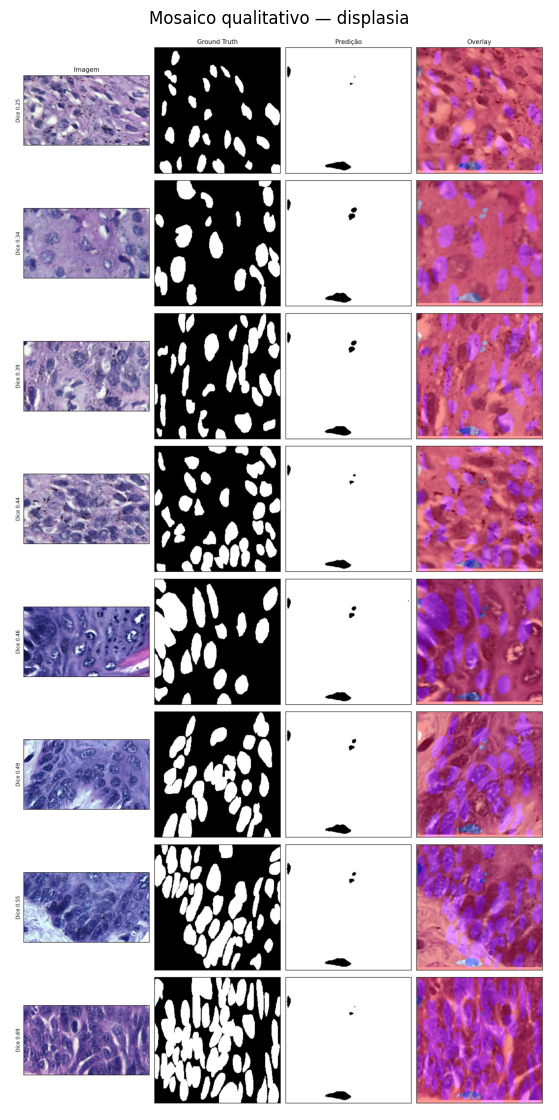


TUMORAL
✓ Mosaico encontrado:
/content/drive/MyDrive/Central/Estudo/LIPAI - Lab de Pesquisa em Imagens/Onboarding/projeto 3/Repositorio/results/qualitative/mosaico_tumoral.png


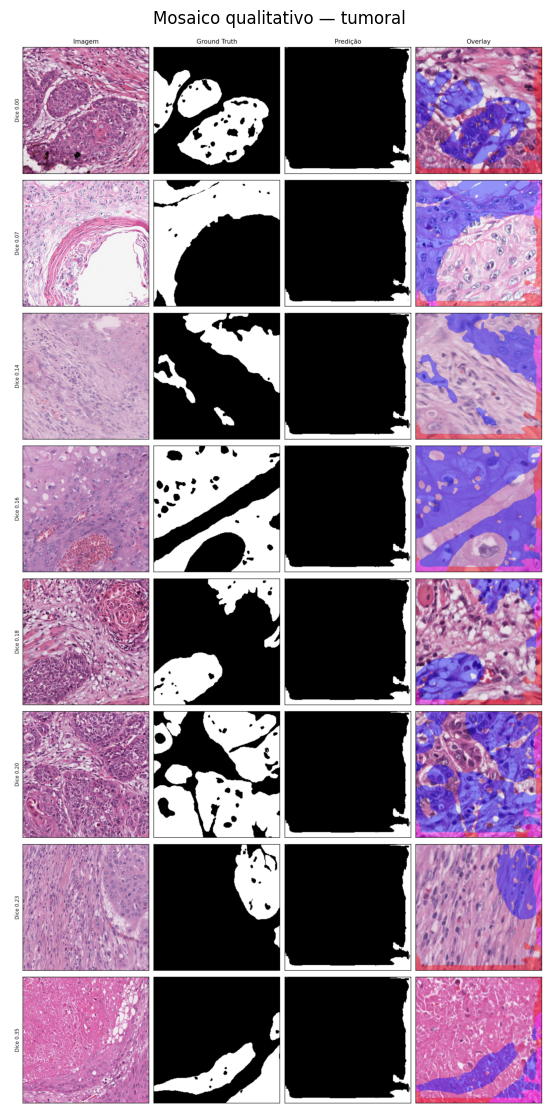

In [103]:
# ============================================================
# 18. RESULTADOS QUALITATIVOS
# ============================================================

mosaicos = {
    'displasia': os.path.join(
        QUALITATIVE_DIR,
        'mosaico_displasia.png'
    ),

    'tumoral': os.path.join(
        QUALITATIVE_DIR,
        'mosaico_tumoral.png'
    )
}

for dataset, caminho in mosaicos.items():

    print("\n" + "=" * 70)
    print(
        dataset.upper()
    )
    print("=" * 70)

    if os.path.exists(caminho):

        print(
            f"✓ Mosaico encontrado:\n{caminho}"
        )

        img = Image.open(
            caminho
        )

        plt.figure(
            figsize=(14, 14)
        )

        plt.imshow(
            img
        )

        plt.axis(
            'off'
        )

        plt.title(
            f'Mosaico qualitativo — {dataset}'
        )

        plt.show()

    else:

        print(
            f"✗ Mosaico não encontrado:\n{caminho}"
        )

19. Síntese final automática

In [104]:
# ============================================================
# 19. SÍNTESE FINAL DOS RESULTADOS
# ============================================================

def melhor_por_fator(
    df,
    dataset,
    fator,
    metrica='mDice_test'
):

    temp = df[
        df['dataset']
        == dataset
    ]

    resultado = (
        temp
        .groupby(fator)
        [metrica]
        .agg([
            'mean',
            'std'
        ])
        .reset_index()
        .sort_values(
            'mean',
            ascending=False
        )
    )

    return resultado


for dataset in [
    'displasia',
    'tumoral'
]:

    print(
        "\n"
        + "=" * 90
    )

    print(
        f"SÍNTESE FINAL — {dataset.upper()}"
    )

    print(
        "=" * 90
    )

    # --------------------------------------------------------
    # Melhor configuração
    # --------------------------------------------------------

    temp = df_analise[
        df_analise['dataset']
        == dataset
    ]

    best = temp.loc[
        temp[
            'mDice_test_mean'
        ].idxmax()
    ]

    print(
        "\n🏆 MELHOR CONFIGURAÇÃO"
    )

    print(
        f"Modelo       : {best['model']}"
    )

    print(
        f"Treinamento  : {best['training_mode']}"
    )

    print(
        f"Loss         : {best['loss']}"
    )

    print(
        f"Augmentation : {best['augmentation']}"
    )

    print(
        f"mDice        : "
        f"{best['mDice_test_mean']:.4f} "
        f"± {best['mDice_test_std']:.4f}"
    )

    print(
        f"mIoU         : "
        f"{best['mIoU_test_mean']:.4f} "
        f"± {best['mIoU_test_std']:.4f}"
    )


    # --------------------------------------------------------
    # Melhor arquitetura — comparação FS
    # --------------------------------------------------------

    arch_temp = df_arch[
        df_arch['dataset']
        == dataset
    ]

    arch_result = (
        arch_temp
        .groupby('model')
        ['mDice_test']
        .mean()
        .sort_values(
            ascending=False
        )
    )

    print(
        "\n🏗️ MELHOR ARQUITETURA (FS)"
    )

    print(
        f"{arch_result.index[0]} "
        f"→ {arch_result.iloc[0]:.4f}"
    )


    # --------------------------------------------------------
    # Melhor loss
    # --------------------------------------------------------

    loss_result = melhor_por_fator(
        df_final,
        dataset,
        'loss'
    )

    print(
        "\n📉 MELHOR FUNÇÃO DE PERDA"
    )

    print(
        f"{loss_result.iloc[0]['loss']} "
        f"→ {loss_result.iloc[0]['mean']:.4f}"
    )


    # --------------------------------------------------------
    # Augmentation
    # --------------------------------------------------------

    aug_result = melhor_por_fator(
        df_final,
        dataset,
        'augmentation'
    )

    print(
        "\n🧬 MELHOR CONDIÇÃO DE AUGMENTATION"
    )

    print(
        f"{aug_result.iloc[0]['augmentation']} "
        f"→ {aug_result.iloc[0]['mean']:.4f}"
    )


    # --------------------------------------------------------
    # FS × PT-ALL
    # --------------------------------------------------------

    pre_temp = df_pretraining[
        df_pretraining['dataset']
        == dataset
    ]

    pre_result = (
        pre_temp
        .groupby('training_mode')
        ['mDice_test']
        .mean()
        .sort_values(
            ascending=False
        )
    )

    print(
        "\n🧠 MELHOR MODO NA U-NET RESNET18"
    )

    print(
        f"{pre_result.index[0]} "
        f"→ {pre_result.iloc[0]:.4f}"
    )


SÍNTESE FINAL — DISPLASIA

🏆 MELHOR CONFIGURAÇÃO
Modelo       : unet_resnet18
Treinamento  : PT-ALL
Loss         : dice
Augmentation : com_aug
mDice        : 0.8253 ± 0.0035
mIoU         : 0.7095 ± 0.0048

🏗️ MELHOR ARQUITETURA (FS)
sharp_unet → 0.8098

📉 MELHOR FUNÇÃO DE PERDA
dice → 0.8063

🧬 MELHOR CONDIÇÃO DE AUGMENTATION
com_aug → 0.8110

🧠 MELHOR MODO NA U-NET RESNET18
PT-ALL → 0.8206

SÍNTESE FINAL — TUMORAL

🏆 MELHOR CONFIGURAÇÃO
Modelo       : unet_resnet18
Treinamento  : PT-ALL
Loss         : bce
Augmentation : com_aug
mDice        : 0.9070 ± 0.0107
mIoU         : 0.8302 ± 0.0179

🏗️ MELHOR ARQUITETURA (FS)
sharp_unet → 0.8605

📉 MELHOR FUNÇÃO DE PERDA
bce → 0.8632

🧬 MELHOR CONDIÇÃO DE AUGMENTATION
com_aug → 0.8618

🧠 MELHOR MODO NA U-NET RESNET18
PT-ALL → 0.8950


20. Bônus

In [105]:
# ============================================================
# TABELA FINAL PARA DISCUSSÃO
# ============================================================

resumo_final = []

for dataset in [
    'displasia',
    'tumoral'
]:

    temp = df_analise[
        df_analise['dataset']
        == dataset
    ]

    best = temp.loc[
        temp[
            'mDice_test_mean'
        ].idxmax()
    ]

    resumo_final.append({
        'dataset':
            dataset,

        'melhor_modelo':
            best['model'],

        'training_mode':
            best['training_mode'],

        'loss':
            best['loss'],

        'augmentation':
            best['augmentation'],

        'mDice':
            best['mDice_test_mean'],

        'mDice_std':
            best['mDice_test_std'],

        'mIoU':
            best['mIoU_test_mean'],

        'precision':
            best[
                'precision_foreground_test_mean'
            ],

        'recall':
            best[
                'recall_foreground_test_mean'
            ]
    })


df_resumo_final = pd.DataFrame(
    resumo_final
)

display(
    df_resumo_final
)

,dataset,melhor_modelo,training_mode,loss,augmentation,mDice,mDice_std,mIoU,precision,recall
0,displasia,unet_resnet18,PT-ALL,dice,com_aug,0.825333,0.003496,0.709533,0.778067,0.725533
1,tumoral,unet_resnet18,PT-ALL,bce,com_aug,0.907000,0.010736,0.830167,0.902267,0.887700


# 21. Matriz de Confusão dos Melhores Modelos

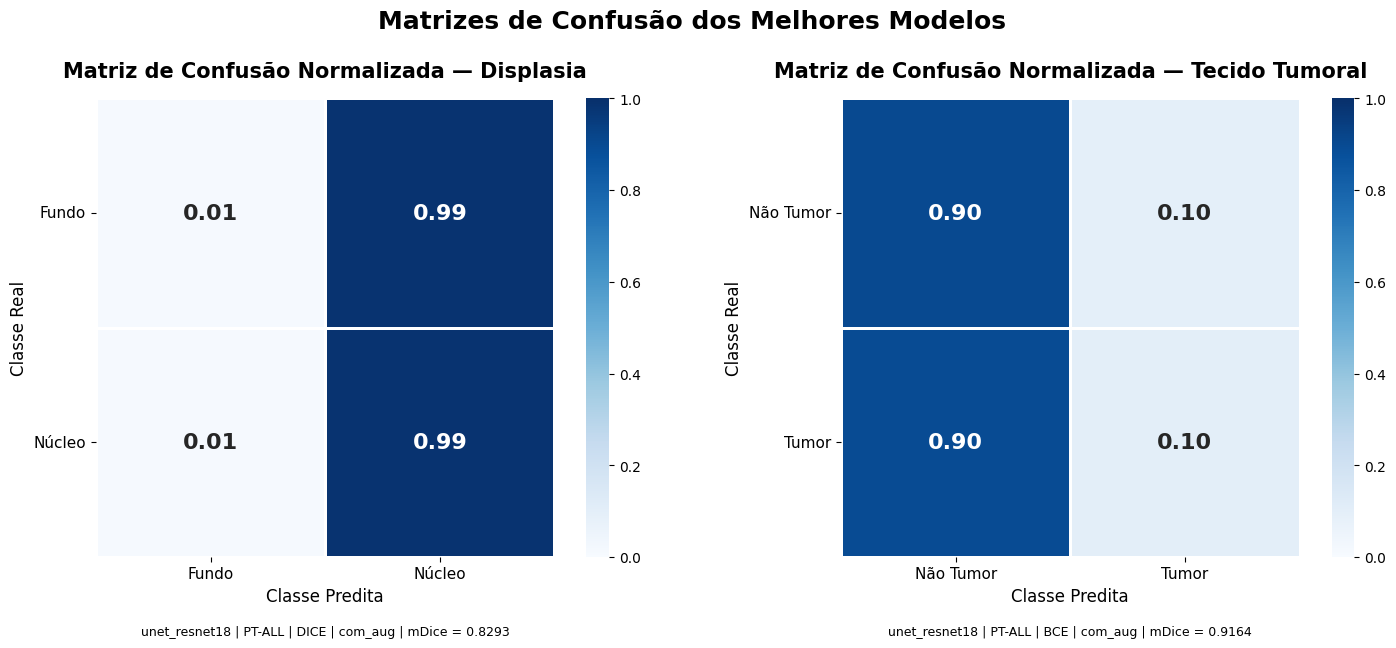

✓ PNG salvo em: /content/drive/MyDrive/Central/Estudo/LIPAI - Lab de Pesquisa em Imagens/Onboarding/projeto 3/Repositorio/results/plots_pdf/matrizes_confusao_melhores_modelos.png
✓ PDF salvo em: /content/drive/MyDrive/Central/Estudo/LIPAI - Lab de Pesquisa em Imagens/Onboarding/projeto 3/Repositorio/results/plots_pdf/matrizes_confusao_melhores_modelos.pdf


In [106]:
# ============================================================
# 21. MATRIZES DE CONFUSÃO NORMALIZADAS
# MELHOR MODELO DE CADA DATASET
# ============================================================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix


@torch.no_grad()
def calcular_matriz_confusao(
    dataset_name,
    eval_ds,
    df_final,
    checkpoints_dir,
    device,
    threshold=0.5
):
    # --------------------------------------------------------
    # MELHOR EXECUÇÃO DO DATASET
    # --------------------------------------------------------

    df_dataset = df_final[
        df_final['dataset'] == dataset_name
    ].copy()

    if df_dataset.empty:
        raise ValueError(
            f"Nenhuma execução encontrada para {dataset_name}."
        )

    best_row = (
        df_dataset
        .sort_values(
            'mDice_test',
            ascending=False
        )
        .iloc[0]
    )

    run_id = best_row['run_id']

    # --------------------------------------------------------
    # MODELO
    # --------------------------------------------------------

    model = build_model(
        best_row['model'],
        best_row['training_mode']
    ).to(device)

    checkpoint_path = os.path.join(
        checkpoints_dir,
        f'best_{run_id}.pth'
    )

    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(
            f"Checkpoint não encontrado:\n{checkpoint_path}"
        )

    state_dict = torch.load(
        checkpoint_path,
        map_location=device
    )

    junk_keys = [k for k in state_dict if k.endswith('total_ops') or k.endswith('total_params')]
    if junk_keys:
        for k in junk_keys:
            state_dict.pop(k)

    model.load_state_dict(state_dict)
    model.eval()

    # --------------------------------------------------------
    # DATALOADER
    # --------------------------------------------------------

    loader = DataLoader(
        eval_ds,
        batch_size=8,
        shuffle=False,
        num_workers=0
    )

    y_true = []
    y_pred = []

    # --------------------------------------------------------
    # INFERÊNCIA
    # --------------------------------------------------------

    for images, masks, _ in loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.sigmoid(outputs)

        predictions = (
            probabilities >= threshold
        ).long().cpu().numpy()

        targets = (
            masks >= 0.5
        ).long().cpu().numpy()

        y_true.append(
            targets.reshape(-1)
        )

        y_pred.append(
            predictions.reshape(-1)
        )

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    # --------------------------------------------------------
    # MATRIZ NORMALIZADA
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
        normalize='true'
    )

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return cm, best_row


# ============================================================
# CALCULA AS DUAS MATRIZES
# ============================================================

cm_displasia, best_displasia = calcular_matriz_confusao(
    dataset_name='displasia',
    eval_ds=ds_displasia,
    df_final=df_final,
    checkpoints_dir=CHECKPOINTS_DIR,
    device=device
)

cm_tumoral, best_tumoral = calcular_matriz_confusao(
    dataset_name='tumoral',
    eval_ds=ds_tumoral,
    df_final=df_final,
    checkpoints_dir=CHECKPOINTS_DIR,
    device=device
)


# ============================================================
# VISUALIZAÇÃO
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)


# ------------------------------------------------------------
# DISPLASIA
# ------------------------------------------------------------

sns.heatmap(
    cm_displasia,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=0,
    vmax=1,
    square=True,
    linewidths=1,
    linecolor='white',
    xticklabels=[
        'Fundo',
        'Núcleo'
    ],
    yticklabels=[
        'Fundo',
        'Núcleo'
    ],
    annot_kws={
        'size': 16,
        'weight': 'bold'
    },
    cbar=True,
    ax=axes[0]
)

axes[0].set_title(
    'Matriz de Confusão Normalizada — Displasia',
    fontsize=15,
    fontweight='bold',
    pad=15
)

axes[0].set_xlabel(
    'Classe Predita',
    fontsize=12
)

axes[0].set_ylabel(
    'Classe Real',
    fontsize=12
)

axes[0].tick_params(
    axis='both',
    labelsize=11
)

axes[0].set_xticklabels(
    axes[0].get_xticklabels(),
    rotation=0
)

axes[0].set_yticklabels(
    axes[0].get_yticklabels(),
    rotation=0
)


# ------------------------------------------------------------
# TECIDO TUMORAL
# ------------------------------------------------------------

sns.heatmap(
    cm_tumoral,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=0,
    vmax=1,
    square=True,
    linewidths=1,
    linecolor='white',
    xticklabels=[
        'Não Tumor',
        'Tumor'
    ],
    yticklabels=[
        'Não Tumor',
        'Tumor'
    ],
    annot_kws={
        'size': 16,
        'weight': 'bold'
    },
    cbar=True,
    ax=axes[1]
)

axes[1].set_title(
    'Matriz de Confusão Normalizada — Tecido Tumoral',
    fontsize=15,
    fontweight='bold',
    pad=15
)

axes[1].set_xlabel(
    'Classe Predita',
    fontsize=12
)

axes[1].set_ylabel(
    'Classe Real',
    fontsize=12
)

axes[1].tick_params(
    axis='both',
    labelsize=11
)

axes[1].set_xticklabels(
    axes[1].get_xticklabels(),
    rotation=0
)

axes[1].set_yticklabels(
    axes[1].get_yticklabels(),
    rotation=0
)


# ============================================================
# TÍTULO GERAL
# ============================================================

fig.suptitle(
    'Matrizes de Confusão dos Melhores Modelos',
    fontsize=18,
    fontweight='bold',
    y=1.03
)


# ============================================================
# INFORMAÇÕES DOS MODELOS
# ============================================================

texto_displasia = (
    f"{best_displasia['model']} | "
    f"{best_displasia['training_mode']} | "
    f"{str(best_displasia['loss']).upper()} | "
    f"{best_displasia['augmentation']} | "
    f"mDice = {best_displasia['mDice_test']:.4f}"
)

texto_tumoral = (
    f"{best_tumoral['model']} | "
    f"{best_tumoral['training_mode']} | "
    f"{str(best_tumoral['loss']).upper()} | "
    f"{best_tumoral['augmentation']} | "
    f"mDice = {best_tumoral['mDice_test']:.4f}"
)

axes[0].text(
    0.5,
    -0.17,
    texto_displasia,
    transform=axes[0].transAxes,
    ha='center',
    fontsize=9
)

axes[1].text(
    0.5,
    -0.17,
    texto_tumoral,
    transform=axes[1].transAxes,
    ha='center',
    fontsize=9
)


# ============================================================
# AJUSTE FINAL
# ============================================================

plt.tight_layout()


# ============================================================
# SALVAR
# ============================================================

png_path = os.path.join(
    PLOTS_DIR,
    'matrizes_confusao_melhores_modelos.png'
)

pdf_path = os.path.join(
    PLOTS_DIR,
    'matrizes_confusao_melhores_modelos.pdf'
)

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches='tight'
)

fig.savefig(
    pdf_path,
    bbox_inches='tight'
)

plt.show()

print(
    f'✓ PNG salvo em: {png_path}'
)

print(
    f'✓ PDF salvo em: {pdf_path}'
)

In [107]:
# ============================================================
# RESUMO DAS MATRIZES DE CONFUSAO
# ============================================================

resultados_confusao = []

for nome_dataset, cm, best_row in [
    ('displasia', cm_displasia, best_displasia),
    ('tumoral', cm_tumoral, best_tumoral),
]:
    resultados_confusao.append({
        'dataset': nome_dataset,
        'modelo': best_row['model'],
        'training_mode': best_row['training_mode'],
        'loss': best_row['loss'],
        'augmentation': best_row['augmentation'],
        'precision': best_row['precision_foreground_test'],
        'recall': best_row['recall_foreground_test'],
        'specificity': cm[0, 0],
        'dice': best_row['dice_foreground_test'],
        'iou': best_row['iou_foreground_test'],
    })

df_matriz_confusao = pd.DataFrame(resultados_confusao)

display(
    df_matriz_confusao.style.format({
        'precision': '{:.4f}',
        'recall': '{:.4f}',
        'specificity': '{:.4f}',
        'dice': '{:.4f}',
        'iou': '{:.4f}'
    })
)

,dataset,modelo,training_mode,loss,augmentation,precision,recall,specificity,dice,iou
0,displasia,unet_resnet18,PT-ALL,dice,com_aug,0.7762,0.7397,0.0127,0.7575,0.6097
1,tumoral,unet_resnet18,PT-ALL,bce,com_aug,0.9045,0.9077,0.9044,0.9061,0.8283
